<a href="https://colab.research.google.com/github/nay-ramos/FinalProject_AirBNB/blob/main/titanic_deaths_breakdown.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**# Classificação com Feature de Profiling via Clustering (TITANIC)**

Projeto feito para a disciplina Machine Learning do curso de Residência em Análise de Dados e IA do Cesar School - 2026.1


### **1. INTRODUÇÃO**

Será que existe algum padrão que nos permita identificar a possibilidade de alguém ter morrido ou sobrevivido no desastre do Titanic? Esse projeto tem como objetivo tentar classificar as chances de vida dos passageiros do navio com base nos dados apresentados no dataset em questão. Para isso vamos:
* Entender o dataset e o acidente do Titanic
* Identificar o melhor baseline de classificação supervisionado
* Fazer o Profiling utilizando clustering e enriquecer a base com features manuais
* Realizar uma comparação entre o dataset enriquecido e não enriquecido

---

####Sobre a viagem:
O Titanic (1912) partiu de Southampton, Inglaterra (10/04), com paradas em Cherbourg, França, e Queenstown (atual Cobh), Irlanda, rumo a Nova Iorque. O navio seguia pelo Atlântico Norte quando colidiu com um iceberg em 14/04, afundando a cerca de 600km do Canadá. Ao todo, haviam 840 cabines no navio, sendo 416 de primeira classe, 162 de segunda classe e 262 de terceira classe.

---

####Sobre o dataset:

As observações feitas são sobre os passageiros à bordo do Titanic que são caracterizados quanto à seu sexo, idade, classe da passagem, número de irmãos ou côjujes à bordo, número de filhos à bordo, valor pago pela passagem inteira e porto de embarque. Além disso, é identificado se eles faleceram ou não no acidente.

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `survived` | Categórica | 1 = sobreviveu, 0 = não sobreviveu |
| `name` | Textual | Nome completo do(a) passageiro(a)|
| `pclass` | Numérica | Classe da passagem (1, 2 ou 3) |
| `sex` | Categórica | gênero do passageiro |
| `age` | Numérica | Idade em anos (contém valores ausentes) |
| `sibsp` | Numérica | Número de irmãos ou cônjuges a bordo |
| `parch` | Numérica | Número de pais ou filhos a bordo |
| `Ticket` | Categórica | código da passagem |
| `fare` | Numérica | Tarifa paga pela passagem |
| `Cabin` | Categórica | Cabine reservada para estadia|
| `Boat` | categórica | bote salva-vidas |
| `Body` | Categórica |  Body Identification Number |
| `home.dest` | Textual| Origem \ Destino |
| `embarked` | Categórica | embarque: C=Cherbourg, Q=Queenstown, S=Southampton |


### **2. Carregamento dos dados**

Importação dos dados do dataset Titanic3 do Scikit-learn, visualização de informações gerais, tipos, campos nulos e estatísticas dos campos numéricos além de uma distribuição inicial do target ( `survived` )

In [ ]:
# configurações iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import plotly.express as px
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    auc,
    precision_recall_curve,
    recall_score,
    precision_score,
)

# semente de aleatoriedade
SEED = 42

In [ ]:
# Carregar dataset
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
df_raw = pd.concat([X, y], axis=1)
df_raw.head(8)

# dic para facilitar o entendimento
target_name_map = {1: "Sobreviveu", 0: "Não sobreviveu"}

####•  **Informações Gerais**

In [ ]:
# informações gerais

df_raw.info()
print('\n■■■■■■■■■■■■■■■■■' )
print('Valores ausentes:')
print('■■■■■■■■■■■■■■■■■' )
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0].to_string())

print('\n■■■■■■■■■■■■■■■■■■■■' )
print('Disribuição de tipos:')
print('■■■■■■■■■■■■■■■■■■■■' )
print(df_raw.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
 13  survived   1309 non-null   category
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB

■■■■■■■■■■■■■■■■■
Valores ausentes:
■■■■■■■■■■■■■■■■■
age           263
fare            1
cabin        1014
embarked        2
boat          823
body         11

####•  **Estatísticas gerais**

In [ ]:
# estatísticas gerais das classes numéricas
df_raw.describe()

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [ ]:
# estatísticas gerais das classes categóricas
df_raw.select_dtypes(include=['object', 'category']).describe(include="all")

,name,sex,ticket,cabin,embarked,boat,home.dest,survived
count,1309,1309,1309,295,1307,486,745,1309
unique,1307,2,929,186,3,27,369,2
top,"Kelly, Mr. James",male,CA. 2343,C23 C25 C27,S,13,"New York, NY",0
freq,2,843,11,6,914,39,64,809


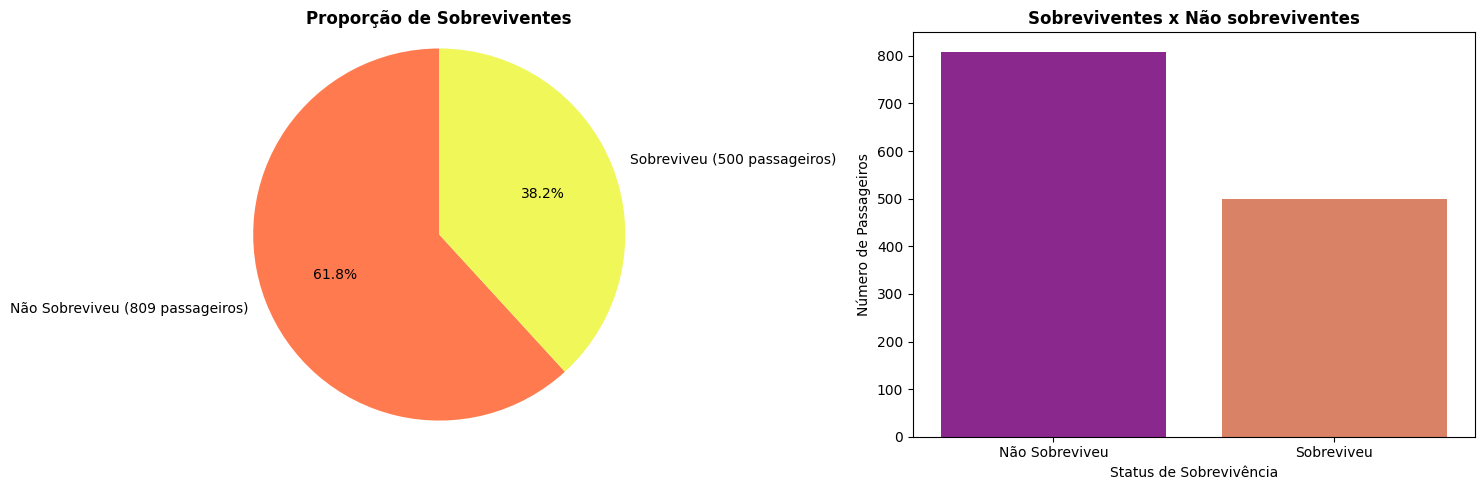

In [ ]:
# contagem total
target_count = df_raw['survived'].value_counts()

# organização dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Proporção de sobreviventes vs. não sobreviventes
sizes = target_count.values
cols_pie = ['#FF7B4F', '#EFF759']
labels_pie = [f"Não Sobreviveu ({target_count.iloc[0]} passageiros)", f"Sobreviveu ({target_count.iloc[1]} passageiros)"]

axs[0].pie(sizes, labels=labels_pie, autopct='%1.1f%%', startangle=90, colors=cols_pie)
axs[0].set_title('Proporção de Sobreviventes', fontsize=12, fontweight='bold')
axs[0].axis('equal')

# Quantidade de sobreviventes vs. não sobreviventes
sns.countplot(data=df_raw, x='survived', ax=axs[1], palette='plasma', hue='survived')
axs[1].set_title('Sobreviventes x Não sobreviventes',fontsize=12, fontweight='bold')
axs[1].set_xlabel('Status de Sobrevivência')
axs[1].set_ylabel('Número de Passageiros')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['Não Sobreviveu', 'Sobreviveu'])

plt.tight_layout()
plt.show()

**Com base nessas informações podemos entender que:**
1. 90% dos corpos não foram identificados (possivelmente não foram encontrados) e o ideal seria que 38% desse valor fosse nulo, para equiparar com a proporção de sobreviventes, portanto, as ausências nesse campo têm alto impacto.
1. 62% dos passageiros estão associados à botes, valor muito próximo da taxa de sobrevivência, o que pode indicar uma grande relação entre estar num bote e ter sobrevivido e os campos nulos nessa entidade na verdade são relevantes para a análise.
1. A maior parte das cabines não é única, indicando pessoas que estavam juntas no mesmo quarto (família/casal)
1. Pelo menos metade dos passageiros foram completamente desacompanhados.
1. Pelo menos metade dos passageiros são da terceira classe.
1. Muitos tickets não são únicos, demonstrando que ele não é associado necessariamente à um passageiro mas sim à uma compra. Essa compra, que pode conter mais de um passageiro nessa compra.
1. A grande maioria dos passageiros embarcou em Southampton (local de partida do navio)


### **3. EDA**

Etapas da exploração:
- Análise do contexto
- Seleção inicial de features
- Exploração e análise de features
- Análise visual
- Seleção final de features

####•  **Análise do Conxtexto**

Localização dos passageiros:
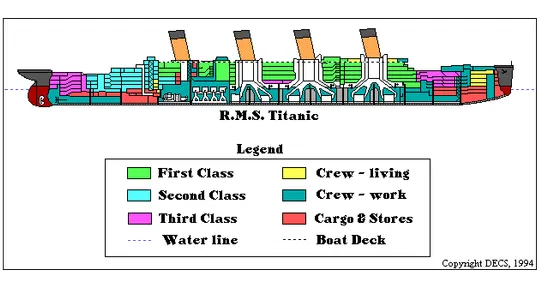


Detalhes das localizações por deck: [veja aqui](https://www.reddit.com/r/titanicfanfiction/comments/193i7g5/hello_i_found_a_great_and_detailed_plan_of_each/#lightbox)


1. As cabines de primeira classe, e algumas da segunda, ficam na parte superior do navio. Permitindo uma vista mais ampla (panorâmica) aos passageiros.
2. As cabines da terceira classe estão nos extremos do navio, e na parte mais baixa.
3. A maior parte dos locais de trabalho do navio são na parte inferior
4. Às 11h a maioria dos passageiros estavam em suas cabines
5. 11h35 o iceberg foi avistado mas era tarde demais pra evitar a colisão
6. Cada cabine começa com a letra do deck no qual está localizada, o deck é o "andar" do navio. ordem dos decks: Botes, A, B, C, D, E, F e G
7. O deck E é o único que tem cabines das 3 classes
8. Na terceira classe homens solteiros ficavam na parte dianteria do navio enquanto as mulheres ficavam na parte traseira



Incidente:

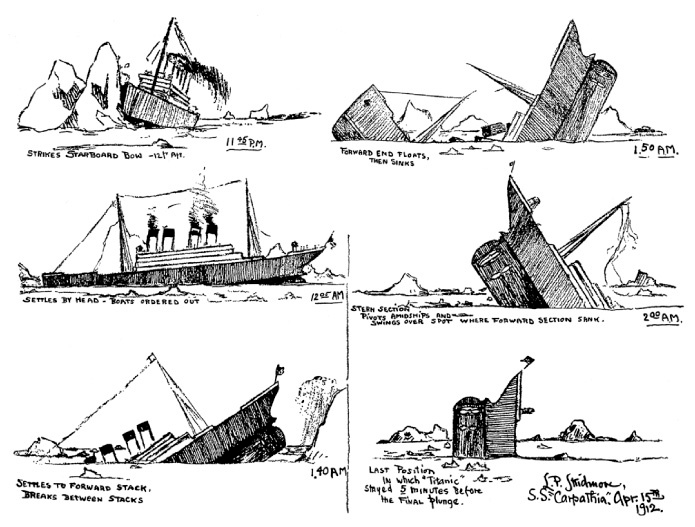

1. Ponto de colisão: estibordo abaixo da linha d'água.
2. Tipo de dano: vários buracos pequenos que permitiram a entrada da água na parte inferior do navio
3. Navio afundou em 2h40min

Segurança:

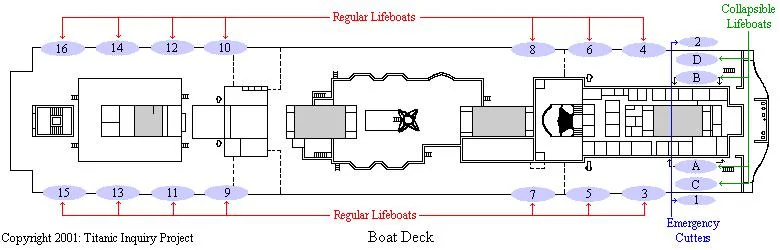
1. Total de Botes: 20 no total (16 de madeira + 4 dobráveis tipo "Engelhardt").
2. O andar de botes era o mais alto, ficava próximo ao comando do navio e acima da primeira classe.
3. O deck G foi o primeiro afetado pelo acidente

####• **Seleção inicial de features**

 #### # Colunas para remoção
| Coluna | Descrição |  motivo|
|--------|------| -----------|
| `name` | Nome completo do(a) passageiro(a)| identifica quase unicamenta o passageiro e, por tanto, não nos dar características relevantes para um agrupamento|
| `Body` |  Body Identification Number | Apenas dá informações sobre o grupo de falecidos e não contribui para a classificação em especial por 90% dos dados estarem nulos
| `home.dest` | Origem \ Destino | esses dados poderiam identificar características sociais. Essas questões já estão bem classificadas nas features "ticket Class" e "fare"


 #### # Colunas para considerar
  | Coluna | Descrição |  motivo|
|--------|----------| -----------|
 | `Cabin`  | Cabine reservada para estadia| As cabines tem as informações dos decks onde os passageiros estavam porém essa coluna tem muitos nulos.
| `embarked`  | Porto de embarque: C = Cherbourg, Q = Queenstown, S = Southampton | Mesmo caráter de `home.dest`, incerto se ele agrega valor ou adiciona complexidade desnecessária então é importante testar.

  #### # Colunas para manter
  | Coluna | Descrição | motivo |
|--------|----------| -----------|
| `survived` | 1 = sobreviveu, 0 = não sobreviveu | variável target
| `ticket`  | Código da passagem | tem relação com a fare e pode deixar essa informação mais rica|
| `pclass` | Classe da passagem (1, 2 ou 3) | verificar a influência da classe x sobrevivência
| `sex` | gênero do passageiro | informação social importante
| `age`  | Idade em anos | verificar a influência da idade x sobrevivência
| `sibsp` | Número de irmãos ou cônjuges a bordo | verificar a influência de não estar sozinho x sobrevivência
| `parch` | Número de pais ou filhos a bordo | verificar a influência de não estar sozinho x sobrevivência
| `fare`  | Tarifa paga pela passagem | verificar a influencia da localização no navio x sobrevivência
| `Boat`  | bote salva-vidas | verificar a influencia de acesso à bote x sobrevivência


In [ ]:
# criação de dataframe para exploração
viz_df = df_raw.drop(['name', 'body', 'home.dest'], axis=1)


In [ ]:
# Conversão de tipo para os gráficos
viz_df['survived'] = viz_df['survived'].astype(int)

[link text](https://)####• **Exploração e Análise de Features**

In [ ]:
# ========== funçoes de apoio =========== #
def group_position_class(pclass, has_family_ob, sex):
    if pclass == 3 and (has_family_ob == 1 or sex == 'female'):
        return 'Back'
    elif pclass == 3 and has_family_ob == 0 and sex == 'male':
          return 'Front'
    elif pclass == 1:
        return 'Center'
    elif pclass == 2:
        return 'Est_center'
    else:
        return 'missing'

In [ ]:
# ====== variáveis e relações para explorar ======

# familia (uniao de sibsp e parch)
viz_df['family_on_board'] = viz_df['sibsp'] + viz_df['parch']

# categorização por ter familia ou nao
viz_df['has_family_ob'] = viz_df['family_on_board'].apply(lambda x: 1 if x > 0 else 0)

# preço da passagem por pessoa (com agrupamento por Ticket)
ticket_counts = viz_df.groupby('ticket')['ticket'].transform('count')
viz_df['people_per_ticket'] = ticket_counts
viz_df['individual_fare'] = viz_df['fare'] / viz_df['people_per_ticket']

# categorização por ter ticket compartilhado ou não
viz_df['has_shared_ticket'] = viz_df['people_per_ticket'].apply(lambda x: 1 if x > 1 else 0)

# conversão de embarket para categorias
viz_df['embarked_S'] = viz_df['embarked'].apply(lambda x: 1 if x == 'S' else 0)
viz_df['embarked_C'] = viz_df['embarked'].apply(lambda x: 1 if x == 'C' else 0)
viz_df['embarked_Q'] = viz_df['embarked'].apply(lambda x: 1 if x == 'Q' else 0)

# remocao de colunas dispensáveis
viz_df.drop(['people_per_ticket'], axis=1, inplace=True)

viz_df.head()

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,survived,family_on_board,has_family_ob,individual_fare,has_shared_ticket,embarked_S,embarked_C,embarked_Q
0,1,female,29.0000,0,0,24160,211.3375,B5,S,2,1,0,0,52.834375,1,1.0,0.0,0.0
1,1,male,0.9167,1,2,113781,151.5500,C22 C26,S,11,1,3,1,25.258333,1,1.0,0.0,0.0
2,1,female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,0,3,1,25.258333,1,1.0,0.0,0.0
3,1,male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,0,3,1,25.258333,1,1.0,0.0,0.0
4,1,female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,0,3,1,25.258333,1,1.0,0.0,0.0


In [ ]:
# Contagem de não sobreviventes em botes salva-vidas
notSurvWboat = viz_df.loc[(viz_df['boat'].notnull()) & (viz_df['survived'] == 0)]


print('\n■■■■■■■■■■■■■■■■■■' )
print('dados sobre botes:')
print('■■■■■■■■■■■■■■■■■■' )
print('Quantidade de botes:', viz_df['boat'].unique().size - 1)
print('Pessoas em cada bote:', viz_df['boat'].value_counts())
print(f"{'■■'*12}")
print('pessoas mortas por bote:', notSurvWboat['boat'].value_counts())

notSurvWboat.head(10)


■■■■■■■■■■■■■■■■■■
dados sobre botes:
■■■■■■■■■■■■■■■■■■
Quantidade de botes: 27
Pessoas em cada bote: boat
13         39
C          38
15         37
14         33
4          31
10         29
5          27
3          26
9          25
11         25
8          23
16         23
7          23
D          20
6          20
12         19
2          13
A          11
B           9
1           5
13 15       2
5 7         2
C D         2
5 9         1
8 10        1
13 15 B     1
15 16       1
Name: count, dtype: int64
■■■■■■■■■■■■■■■■■■■■■■■■
pessoas mortas por bote: boat
A     4
14    1
12    1
D     1
B     1
C     1
Name: count, dtype: int64


,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,survived,family_on_board,has_family_ob,individual_fare,has_shared_ticket,embarked_S,embarked_C,embarked_Q
19,1,male,36.0,0,0,13050,75.2417,C6,C,A,0,0,0,37.62085,1,0.0,1.0,0.0
166,1,male,NaN,0,0,PC 17600,30.6958,NaN,C,14,0,0,0,30.69580,0,0.0,1.0,0.0
544,2,male,34.0,1,0,31027,21.0000,NaN,S,12,0,1,1,10.50000,1,1.0,0.0,0.0
655,3,male,32.0,1,0,3101278,15.8500,NaN,S,D,0,1,1,7.92500,1,1.0,0.0,0.0
853,3,male,25.0,0,0,374887,7.2500,NaN,S,B,0,0,0,7.25000,0,1.0,0.0,0.0
921,3,male,NaN,0,0,323592,7.2500,NaN,S,A,0,0,0,7.25000,0,1.0,0.0,0.0
968,3,male,36.0,1,0,349910,15.5500,NaN,S,A,0,1,1,7.77500,1,1.0,0.0,0.0
969,3,female,30.0,1,0,349910,15.5500,NaN,S,A,0,1,1,7.77500,1,1.0,0.0,0.0
1299,3,male,27.0,1,0,2659,14.4542,NaN,C,C,0,1,1,7.22710,1,0.0,1.0,0.0


In [ ]:
viz_df['position_class'] = viz_df.apply(lambda row: group_position_class(row['pclass'], row['has_family_ob'], row['sex']), axis=1)

groups_loc = viz_df.groupby("position_class").agg(
    n=("ticket", "size"),
    sex_female_count=("sex", lambda x: (x == 'female').sum()),
    sex_male_count=("sex", lambda x: (x == 'male').sum()),
    pclass=("pclass", lambda x: x.iloc[0]),
    has_family_ob=("has_family_ob", lambda x: x.iloc[0])
).round(3)

groups_loc

count_single_pp_3_class = groups_loc.loc[(groups_loc['pclass'] == 3) & (groups_loc['has_family_ob'] == 0)]
print(count_single_pp_3_class)

                  n  sex_female_count  sex_male_count  pclass  has_family_ob
position_class                                                              
Front           372                 0             372       3              0


In [ ]:
# criação da feature on_a_boat
viz_df['on_a_boat'] = viz_df['boat'].apply(lambda x: 1 if pd.notnull(x) else 0)

####• **Análise Visual**

/tmp/ipykernel_714/2180791247.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




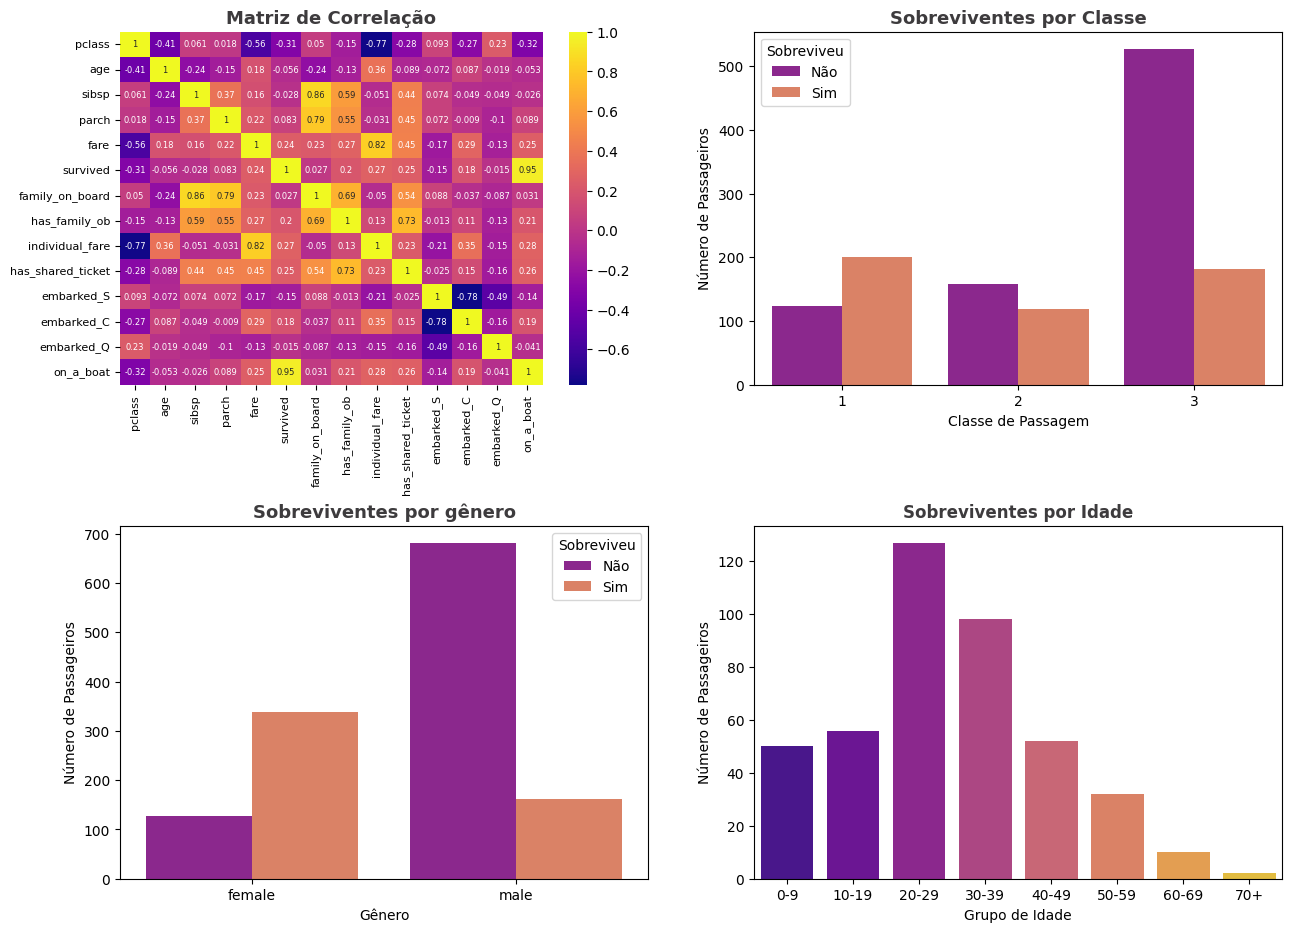

In [ ]:
# seleção de features numéricas
num_df = viz_df.select_dtypes(include=[np.number])

# organização dos gráficos
fig, axs = plt.subplots(2, 2, figsize=(15, 11))

# matriz de correlação
corr = num_df.corr()
sns.heatmap(corr, annot=True, cmap='plasma', ax=axs[0, 0], annot_kws={'size': 6})
axs[0, 0].set_title('Matriz de Correlação', fontsize=13, fontweight='bold', color='#3D3B3D')
axs[0, 0].tick_params(axis='both', labelsize=8)

# sobreviventes por classe
sns.countplot(data=viz_df, x='pclass', hue='survived', ax=axs[0, 1], palette='plasma')
axs[0, 1].set_title('Sobreviventes por Classe', fontsize=13, fontweight='bold', color='#3D3B3D')
axs[0, 1].set_xlabel('Classe de Passagem')
axs[0, 1].set_ylabel('Número de Passageiros')
axs[0, 1].legend(title='Sobreviveu', labels=['Não', 'Sim'])

# sobreviventes por gênero
sns.countplot(data=viz_df, x='sex', hue='survived', ax=axs[1, 0], palette='plasma')
axs[1, 0].set_title('Sobreviventes por gênero', fontsize=13, fontweight='bold', color='#3D3B3D')
axs[1, 0].set_xlabel('Gênero')
axs[1, 0].set_ylabel('Número de Passageiros')
axs[1, 0].legend(title='Sobreviveu', labels=['Não', 'Sim'])

# bins para a idade
bins = [0, 10, 20, 30, 40, 50, 60, 70, viz_df['age'].max() + 5]
labels_age = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
viz_df['age_group'] = pd.cut(viz_df['age'], bins=bins, labels=labels_age, right=False)

# sobreviventes por grupo etário
df_survivors = viz_df[viz_df['survived'] == 1]

sns.countplot(data=df_survivors, x='age_group', ax=axs[1,1], palette='plasma')
axs[1,1].set_title('Sobreviventes por Idade', fontsize=12, fontweight='bold', color='#3D3B3D')
axs[1,1].set_xlabel('Grupo de Idade')
axs[1,1].set_ylabel('Número de Passageiros')

plt.subplots_adjust(hspace = 0.4)
plt.show()

####•  **Seleção final de features**

Tomando como base a matriz de correlação, observa-se a divisão abaixo:

Correlação significativa:
- `on_a_boat`
- `has_shared_ticket`
- `pclass`  *(a relação é invesa porque a feature está em formato numérico 1 é um número baixo enquanto 1ª é a classe mais alta)*
- `individual_fare`
- `has_family_ob`
- `embarket_S`
- `embarket_C`
- `fare`

Correlação nula ou insignificante:
- `age`
- `family_on_board`
- `embarked_Q`
- `parch`
- `sibs`

### Seleção:

 | baseline | feature eng. |
|--------|----------|
| `pclass`| `individual_fare`
| `sex` | `has_family_ob`
|`embarked`| `has_shared_ticket`
|`fare`| `family_on_board`



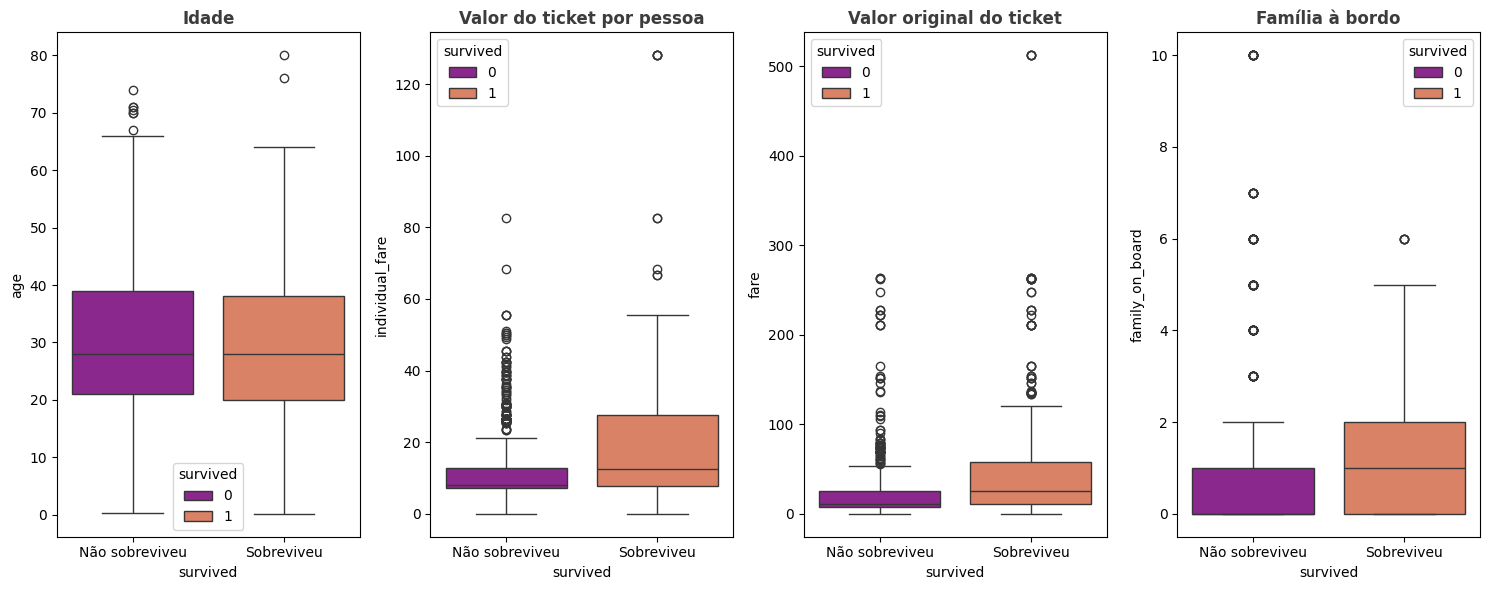

In [ ]:
# box plot comparativo de features numéricas
fig, axes = plt.subplots(1, 4, figsize=(15, 6))

sns.boxplot(data=viz_df, x="survived", y="age", ax=axes[0], palette='plasma', hue='survived')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([target_name_map[int(t.get_text())] for t in axes[0].get_xticklabels()])
axes[0].set_title("Idade", color='#3D3B3D', fontweight='bold', fontsize=12 )

sns.boxplot(data=viz_df, x="survived", y="individual_fare", ax=axes[1], palette='plasma', hue='survived')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels([target_name_map[int(t.get_text())] for t in axes[1].get_xticklabels()])
axes[1].set_title("Valor do ticket por pessoa", color='#3D3B3D', fontweight='bold', fontsize=12)

sns.boxplot(data=viz_df, x="survived", y="fare", ax=axes[2], palette='plasma', hue='survived')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels([target_name_map[int(t.get_text())] for t in axes[2].get_xticklabels()])
axes[2].set_title("Valor original do ticket", color='#3D3B3D', fontweight='bold', fontsize=12)

sns.boxplot(data=viz_df, x="survived", y="family_on_board", ax=axes[3], palette='plasma', hue='survived')
axes[3].set_xticks([0, 1])
axes[3].set_xticklabels([target_name_map[int(t.get_text())] for t in axes[3].get_xticklabels()])
axes[3].set_title("Família à bordo", color='#3D3B3D', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

####•  **Revelações sobre a Análise Exploratória**

1. A forma como o navio é organizado em classes posiciona os passageiros mais acima ou abaixo e mais centrais ou extremos em relação ao navio. O fato das classes se misturam em alguns decks pode ou não ser um fator que diminua a correlação entre a feature pclass e o targetcorrelação entre a feature `pclass` e o `target`
2. A feature `cabins` possui muitos campos nulos e é uma feature chave para indicar a localização dos passageiros, da forma como está, não pode ser usada. Talvez, com uso de clustering, podemos tentar recuperá-la.
3. Esse dataset não inclui tripulação. Todas as observações têm classe, característica que não se aplica aos tripulantes do navio. Isso significa que é possível que tripulantes tenham ocupado espaços em botes, mas não temos essa informação.
3. Apesar da quantidade de homens à bordo ser maior que a de mulheres, a proporção de homens mortos em relação ao total, demonstra que a separação por gênero da terceira classe pode ter influenciado na taxa de sobrevivência mas, principalmente, pode ter havido um ato de abnegação priorizando salvar mulheres e crianças primeiro, como ocorrem em muitas situações de risco.
4. Apesar de ter muito mais cabines na 1ª Classe, a 3ª teve muito mais passageiros.
5. 20 botes salva vidas podem ter sido insuficiente para garantir a segurança de 1309 passageiros, sem contar os tripulantes. E a localização dos botes, acima de tudo, não considerou a distribuição de pessoas ao longo do navio (já que estavam todos no deck superior)
7. As features parch e sibsp, separadamente, tem uma correlação quase nula com os não sobreviventes. Mas a feature has_family_ob tem uma correlação boa com a sobrevivência, apesar de ter menos granularidade comparada com family_on_board.`has_family_ob` tem uma correlação boa com a sobrevivência.
9. O `ticket` não é uma variável individual, parentes, por exemplo, possuem o mesmo `ticket` e o valor é para toda a família. Dividir a `fare` pela quantidade de pessoas por `ticket` gerou a feature `individual_fare` que tem uma correlação linear um pouco melhor que a `fare`
10. As features criadas a partir de `embarked` se mostram com uma correlação interessante com a sobrevivência (exceto `embarkerd_Q`).

---

#### Conclusões
1. Tentar aproveitar o potencial de `cabins` com uso de clustering
2. Manter as features que tenham uma boa correlação com o target
3. Remover as features que tenham alta correlação entre si e correlação similar com o target

In [ ]:
df_baseline = df_raw.copy()
df_baseline = df_baseline.drop(['boat', 'home.dest', 'body', 'cabin', 'ticket'], axis=1)


### **4. PRÉ-PROCESSAMENTO**
Etapas:
 - feature engineering de localização
 - tratamento de ausentes
 - encoding e scaling
 - separação dos dados de treino


####•  **Feature Engineering de localização**

Vista a baixíssima correlação das features `parch`, `sibsp` e a união delas (`family_on_board`) as duas primeiras serão removidas para a análise de sobrevivência porém a última será mantida para análise de deck. A feature `boat` serviu para a criação de uma feature de altíssima correlação mas, da forma como está, não contribui muito para a questão "foi ou não sobrevivente" e sim "como sobreviveu" apontado especificamente se deve acesso ou não à bote. A feature  `on_a_boat` pode contribuir para a identificação de deck mas não para a sobrevivência pois seria um data leakage.

Além disso, as features categóricas `cabin` e `ticket` serão removidas. cabin irá derivar nosso target `deck`, dela extrairemos a primeira letra que identifica o local onde provavelmente essa pessoa estava durante o incidente. `Ticket` já serviu para a criação de 2 features mais relevantes que a original: `has_shared_ticket` e `individual_fare`.

In [ ]:
# seleção de features criadas na exploração
df_t = viz_df.drop(['boat', 'parch', 'sibsp', 'ticket', 'embarked_C', 'embarked_S','embarked_Q', 'fare'], axis=1).copy()
# aproveitamento de features testadas na EDA

In [ ]:
# verificar dados da feature cabin
print('Cabines:')
print(df_t['cabin'].unique(), "\n")

# verificar linha com dado incoerente
display(df_t[df_t['cabin'] == 'T'])

# substituir o valor por "B" já que ele é primeira classe e é apenas uma linha
df_t['cabin'] = df_t['cabin'].replace('T', 'B')

# feature cabin para deck
df_t['deck'] = df_t['cabin'].str.get(0)

# verificar dados da feature deck
print('\nDecks:')
print(df_t['deck'].unique())


Cabines:
['B5' 'C22 C26' 'E12' 'D7' 'A36' 'C101' nan 'C62 C64' 'B35' 'A23'
 'B58 B60' 'D15' 'C6' 'D35' 'C148' 'C97' 'B49' 'C99' 'C52' 'T' 'A31' 'C7'
 'C103' 'D22' 'E33' 'A21' 'B10' 'B4' 'E40' 'B38' 'E24' 'B51 B53 B55'
 'B96 B98' 'C46' 'E31' 'E8' 'B61' 'B77' 'A9' 'C89' 'A14' 'E58' 'E49' 'E52'
 'E45' 'B22' 'B26' 'C85' 'E17' 'B71' 'B20' 'A34' 'C86' 'A16' 'A20' 'A18'
 'C54' 'C45' 'D20' 'A29' 'C95' 'E25' 'C111' 'C23 C25 C27' 'E36' 'D34'
 'D40' 'B39' 'B41' 'B102' 'C123' 'E63' 'C130' 'B86' 'C92' 'A5' 'C51' 'B42'
 'C91' 'C125' 'D10 D12' 'B82 B84' 'E50' 'D33' 'C83' 'B94' 'D49' 'D45'
 'B69' 'B11' 'E46' 'C39' 'B18' 'D11' 'C93' 'B28' 'C49' 'B52 B54 B56' 'E60'
 'C132' 'B37' 'D21' 'D19' 'C124' 'D17' 'B101' 'D28' 'D6' 'D9' 'B80' 'C106'
 'B79' 'C47' 'D30' 'C90' 'E38' 'C78' 'C30' 'C118' 'D36' 'D48' 'D47' 'C105'
 'B36' 'B30' 'D43' 'B24' 'C2' 'C65' 'B73' 'C104' 'C110' 'C50' 'B3' 'A24'
 'A32' 'A11' 'A10' 'B57 B59 B63 B66' 'C28' 'E44' 'A26' 'A6' 'A7' 'C31'
 'A19' 'B45' 'E34' 'B78' 'B50' 'C87' 'C116' 'C55 C

,pclass,sex,age,cabin,embarked,survived,family_on_board,has_family_ob,individual_fare,has_shared_ticket,position_class,on_a_boat,age_group
30,1,male,45.0,T,S,0,0,0,35.5,0,Center,0,40-49



Decks:
['B' 'C' 'E' 'D' 'A' nan 'F' 'G']


In [ ]:
# remoção de features cabin
df_t = df_t.drop(['cabin'], axis=1)

# separação do df com deck para testes posteriores
df_w_deck = df_t[df_t['deck'].notnull()].copy()
df_wo_deck = df_t[df_t['deck'].isnull()].copy()

print('\n■■■■■■■■■■■■■■■■■■■■■' )
print('Divisão do dataframe:')
print('■■■■■■■■■■■■■■■■■■■■■' )
print('passageiros com deck:', df_w_deck.shape)
print('passageiros sem deck:', df_wo_deck.shape)

print('\n■■■■■■■■■■■■■' )
print("distribuição:")
print('■■■■■■■■■■■■■' )
print(df_w_deck['deck'].value_counts().sort_index())

print('\n■■■■■■■■■■■■■■■■■■■■■' )
print("deck x sobrevivência:")
print('■■■■■■■■■■■■■■■■■■■■■' )
survival_deck = df_w_deck.groupby(['deck','sex'])['survived'].agg(['mean', 'count'])
survival_deck.columns = ['taxa_sobrevivência', 'qtd_pessoas']
print(survival_deck.sort_values('taxa_sobrevivência', ascending=False))



■■■■■■■■■■■■■■■■■■■■■
Divisão do dataframe:
■■■■■■■■■■■■■■■■■■■■■
passageiros com deck: (295, 13)
passageiros sem deck: (1014, 13)

■■■■■■■■■■■■■
distribuição:
■■■■■■■■■■■■■
deck
A    22
B    66
C    94
D    46
E    41
F    21
G     5
Name: count, dtype: int64

■■■■■■■■■■■■■■■■■■■■■
deck x sobrevivência:
■■■■■■■■■■■■■■■■■■■■■
             taxa_sobrevivência  qtd_pessoas
deck sex                                    
B    female            1.000000           36
F    female            1.000000            8
D    female            1.000000           23
E    female            0.947368           19
C    female            0.913043           46
A    female            0.750000            4
G    female            0.600000            5
E    male              0.545455           22
A    male              0.444444           18
D    male              0.391304           23
F    male              0.384615           13
B    male              0.366667           30
C    male              0.312500          

/tmp/ipykernel_714/315590432.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# ======== classificação de deck por classe ========== #
def group_decks(deck):
    if deck in ['A', 'B', 'C']:
        return 'Upper'
    elif deck in ['D', 'E']:
        return 'Mid'
    elif deck in ['F', 'G']:
        return 'Lower'
    else:
        return 'Unknown'

# data leakage 🙃
""" def group_position_class(pclass, has_family_ob, sex, deck):
    if pclass == 3 and (has_family_ob == 1 or sex == 'female'):
      if deck in ['D', 'E']:
        return 'Mid_back'
      else:
        return 'Low_back'
    elif pclass == 3 and has_family_ob == 0 and sex == 'male':
        if deck in ['D', 'E']:
          return 'Mid_front'
        else:
          return 'Low_front'
    elif pclass == 1 and deck in ['A', 'B', 'C']:
        return 'Upper_center'
    elif pclass == 2 and deck == 'D':
        return 'Mid_back'
    elif pclass == 1 and deck == 'D':
        return 'Mid_front'
    elif pclass != 3 and deck == 'E':
        return 'Mid_Estb'
    elif pclass != 1 and deck == 'F':
       return'Low_center'
    else:
        return 'Unknown' """



df_w_deck['deck_grouped'] = df_w_deck['deck'].apply(group_decks)
df_w_deck['position_class'] = df_w_deck.apply(lambda row: group_position_class(row['pclass'], row['has_family_ob'], row['sex']), axis=1)


##### **Classificação de Deck:**

In [ ]:
# ========== separação de dados para o target Deck ========== #
X_deck = df_w_deck.drop('deck_grouped', axis=1)
le = LabelEncoder()
y_deck = le.fit_transform(df_w_deck['deck_grouped'])

# separação para treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_deck, y_deck,
    test_size=0.2,
    stratify=y_deck,
    random_state=SEED)

# quantidades
print("Treino    :", X_train.shape, y_train.shape)
print("Validação :", X_val.shape, y_val.shape)

Treino    : (236, 13) (236,)
Validação : (59, 13) (59,)


In [ ]:
# ========== criação de pipeline de pré-processamento para decks ========== #
num_cols_deck = ['family_on_board', 'individual_fare',
           'has_shared_ticket']
cat_cols_deck = ['pclass']

# pipeline numérico (o escalonador será substituído no gridsearch)
num_deck_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_deck_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# pre-processador
preprocessor_deck = ColumnTransformer([
    ('num', num_deck_pipeline, num_cols_deck),
    ('cat', cat_deck_pipeline, cat_cols_deck)
])

In [ ]:
# ========= pipeline para cada baseline para deck ========== #
train_features_deck = list(X_train.columns)

deck_candidates = {
    # Regressao Logística
    "LogisticRegression_deck": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor_deck),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=SEED,
            )),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["newton-cg", "sag", "lbfgs"],
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()]
        }
    },
     # Random Forest
    "RandomForest_deck": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor_deck),
            ("model", RandomForestClassifier(
                random_state=SEED,
                class_weight="balanced"
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [250, 300, 350],
            "model__max_depth": [None,8, 10, 12],
            "model__min_samples_leaf": [1, 2, 3],
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()]
        }
    }
}

In [ ]:
cv_d = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

baseline_searches_d = {}

for name, config in deck_candidates.items():
    print(f"\n{'■■'*21}")
    print(f"Treinando: {name}")
    print(f"{'■■'*21}")

    grid_s_d = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="f1_weighted",
        cv=cv_d,
        n_jobs=-1,
        refit=True,
        error_score=0
    )

    # treinamento
    grid_s_d.fit(X_train, y_train)

    baseline_searches_d[name] = {
        'best_score': grid_s_d.best_score_,
        'best_params': grid_s_d.best_params_,
        'best_estimator': grid_s_d.best_estimator_
    }

    # Avaliar no teste
    test_score_d = grid_s_d.score(X_val, y_val)
    baseline_searches_d[name]['test_score'] = test_score_d

    print(f"\n {name} - Melhor score (CV): {grid_s_d.best_score_:.4f}")
    print(f" {name} - Score no teste: {test_score_d:.4f}")
    print(f" Melhores parâmetros: {grid_s_d.best_params_}")

    report = classification_report(y_val, grid_s_d.predict(X_val), target_names=le.classes_)
    print(f"\n{report}")


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Treinando: LogisticRegression_deck
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

 LogisticRegression_deck - Melhor score (CV): 0.6491
 LogisticRegression_deck - Score no teste: 0.6717
 Melhores parâmetros: {'model__C': 10, 'model__solver': 'newton-cg', 'preprocessor__num__scaler': StandardScaler()}

              precision    recall  f1-score   support

       Lower       0.62      1.00      0.77         5
         Mid       0.46      0.67      0.55        18
       Upper       0.88      0.61      0.72        36

    accuracy                           0.66        59
   macro avg       0.66      0.76      0.68        59
weighted avg       0.73      0.66      0.67        59


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Treinando: RandomForest_deck
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

 RandomForest_deck - Melhor score (CV): 0.8015
 RandomForest_deck - Score no teste: 0.7722
 Melhores parâmetros: {'model__max_depth': None, 'model__min_samples

Funções de apoio:

In [ ]:
# matriz de confusão
def plot_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
    plt.title("Matriz de confusão", fontsize=12, fontweight='bold', color='#3D3B3D')
    plt.ylabel("Real")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()


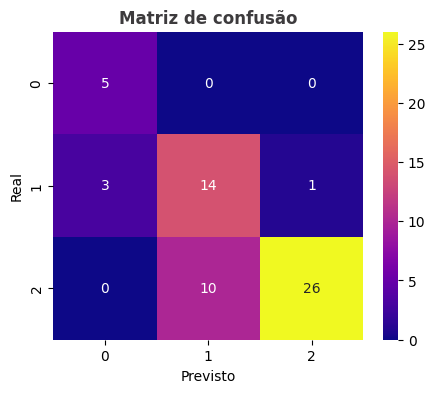

In [ ]:
# seleção do melhor modelo
best_model = baseline_searches_d['RandomForest_deck']['best_estimator']

plot_confusion(y_val, best_model.predict(X_val))

**Conclusões sobre predição de deck_grouped:**
1. O modelo tem mais facilidade para prever os decks mais baixos e dificuldade para diferenciar os decks mais altos
2. Apesar da avaliação por deck ser importante, a localização no navio não é totalmente determinada por isso a localização em si é relevante mas não determinante para a sobrevivência.
3. A diferença da das métricas de treino e teste é baixa, isso mostra consistência no modelo.
4. ao testar a variável `on_a_boat`/`survived` com uma feature para identificar `deck_grouped`, a qualidade da predição caiu o que mostra que essa localização horizontal não é assim tão indicativa de sobrevivência
---

Próximo passo:
Criar a coluna `deck_grouped` para ser usada no modelo enriquecido e testar se ela realmente contribui para a melhoria de qualiade de predição.

####• **divisão de tipo dados para tratamento**

In [ ]:
# separação de dados para o target Survived
X = df_baseline.drop('survived', axis=1)
y = df_baseline['survived'].astype(int)

# separação para teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED)

# separação para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=SEED
)

# quantidades
print("Treino    :", X_train.shape, y_train.shape)
print("Validação :", X_val.shape, y_val.shape)
print("Teste     :", X_test.shape, y_test.shape)

Treino    : (785, 8) (785,)
Validação : (262, 8) (262,)
Teste     : (262, 8) (262,)


####• **Tratamento de nulos, encoding e scaling**

In [ ]:
num_cols_b = ['fare']
cat_cols_b = ['pclass', 'sex', 'embarked']


num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ])

preprocessor = ColumnTransformer([
        ('num', num_pipeline, num_cols_b),
        ('cat', cat_pipeline, cat_cols_b)
    ])


### **5. BASELINE SUPERVISIONADO**

Esse baseline tem features enriquecidas e originais. Seu objetivo é identificar o melhor modelo para essa análise verificando diferentes parâmetros e formas de scaling e, além disso, definir o melhor treshold que se adeque à nosso propósito (identificar sobreviventes)

O motivo desse baseline não conter apenas as features originais é a necessidade identificada de tratar minimamente algumas features de forma a incluir dados relevantes para a identificação do baseline. Porém, na próxima etapa trabalharemos mais profundamento na engenharia de feature.

In [ ]:
# ========= treinamento dos modelos de classificação ========== #


baseline_candidates_sur = {
    "LogisticRegression": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=SEED,
            )),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"],
            "preprocessor__num__scaler": [StandardScaler(),
                                          MinMaxScaler()]
        }
    },
    "RandomForest": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor),
            ("model", RandomForestClassifier(
                random_state=SEED,
                class_weight="balanced"
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [100, 150, 200],
            "model__max_depth": [None, 5, 10, 15],
            "model__min_samples_leaf": [1, 2, 5],
            "preprocessor__num__scaler": [StandardScaler(),
                                          MinMaxScaler()]
        }
    }

 }

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

baseline_searches = {}

for name, config in baseline_candidates_sur.items():
    print(f"\n{'■■'*26}")
    print(f"Treinando: {name}")
    print(f"{'■■'*26}")

    grid_s = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        error_score=0
    )

    # treinamento
    grid_s.fit(X_train, y_train)

    baseline_searches[name] = {
        'best_score': grid_s.best_score_,
        'best_params': grid_s.best_params_,
        'best_estimator': grid_s.best_estimator_
    }

    # Avaliar no teste
    test_score = grid_s.score(X_val, y_val)
    baseline_searches[name]['test_score'] = test_score

    print(f"\n {name} - Melhor score (CV): {grid_s.best_score_:.4f}")
    print(f" {name} - Score no teste: {test_score:.4f}")
    print(f" Melhores parâmetros: {grid_s.best_params_}")


    report = classification_report(y_val, grid_s.predict(X_val), target_names=list(target_name_map.values()))
    print(f"\n{report}")


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Treinando: LogisticRegression
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

 LogisticRegression - Melhor score (CV): 0.6767
 LogisticRegression - Score no teste: 0.7437
 Melhores parâmetros: {'model__C': 0.1, 'model__solver': 'liblinear', 'preprocessor__num__scaler': MinMaxScaler()}

                precision    recall  f1-score   support

    Sobreviveu       0.84      0.85      0.84       162
Não sobreviveu       0.75      0.74      0.74       100

      accuracy                           0.81       262
     macro avg       0.79      0.79      0.79       262
  weighted avg       0.80      0.81      0.81       262


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Treinando: RandomForest
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

 RandomForest - Melhor score (CV): 0.6918
 RandomForest - Score no teste: 0.7158
 Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators':

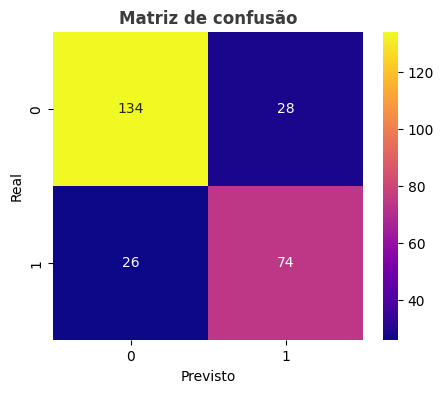


Classification report (Threshold: 0.45):
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       162
           1       0.73      0.74      0.73       100

    accuracy                           0.79       262
   macro avg       0.78      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262


Análise de sensibilidade do Threshold:
Threshold 0.2 -> Precision: 0.528 Recall: 0.860
Threshold 0.4 -> Precision: 0.658 Recall: 0.770
Threshold 0.5 -> Precision: 0.756 Recall: 0.680
Threshold 0.6 -> Precision: 0.788 Recall: 0.670
Threshold 0.7 -> Precision: 0.811 Recall: 0.600
Threshold 0.8 -> Precision: 0.907 Recall: 0.490


In [ ]:
# seleção do melhor modelo e probabilidades
best_model = baseline_searches['RandomForest']['best_estimator']
y_probs = best_model.predict_proba(X_val)[:, 1]

threshold = 0.45
pred_val_baseline = (y_probs >= threshold).astype(int)


# avaliação da matriz de confusão do melhor modelo
plot_confusion(y_val, pred_val_baseline)

print(f"\nClassification report (Threshold: {threshold}):")
print(classification_report(y_val, pred_val_baseline, zero_division=0))

print("\nAnálise de sensibilidade do Threshold:")
for t in [0.2, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (y_probs >= t).astype(int)
    rec = recall_score(y_val, p)
    prec = precision_score(y_val, p)
    print(f"Threshold {t:.1f} -> Precision: {prec:.3f}",  f"Recall: {rec:.3f}")

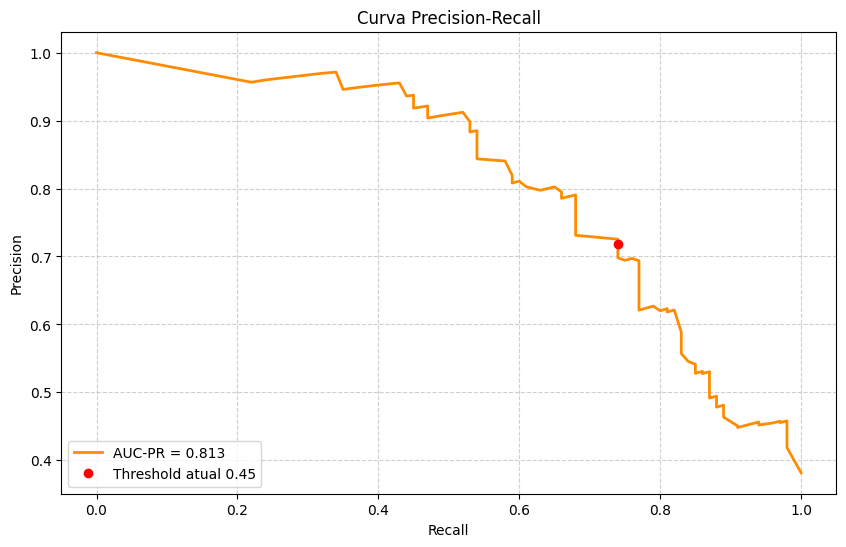

In [ ]:
# Calculando a curva Precisão-Recall
precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, label=f'AUC-PR = {pr_auc:.3f}', color='darkorange', lw=2)

# Plotando o ponto do threshold atual (0.45)
idx = np.argmin(np.abs(thresholds - threshold))
plt.plot(recalls[idx], precisions[idx], 'ro', label=f'Threshold atual {threshold}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Conclusões:

Melhor moldelo: **RandomForest**
| Parâmetros | valor |
|--------|------|
 model__max_depth | None
 model__min_samples_leaf | 1
 model__n_estimators | 100
 scaler | Standard Scaler

Justificativa:

> Comparado à regressão logística, o Random Forest apresentou resultados mais consistentes. Entre Teste e Validação, a diferença foi de 2,5% no Random Forest. No Logistic Regression, o resultado da validação foi 6,8% menor que o do teste, mostrando uma tendência à underfitting, apesar de ser um resultado aceitável, não é o melhor.
---

Threshold: **0.45**

Justificativa:
> Considerando a matriz de confusão, esse treshold resulta na menor quantidade de erros totais `FP+FN`. Além disso, como a prioridade é salvar vidas, priorizar o recall em dentrimento da precision na curva-precision-recall faz sentido para a análise que estamos fazendo.


### **6. Feature Engineering**

#### 6.2 Features Manuais
Agrupamento por idade

#### 6.2 PROFILING (CLUSTERING)
- pré-processamento
- clustering
- avaliação de clustering
- feature derivada
- descrição dos clusterings





In [ ]:
def add_manual_features(X):
  x_new = X.copy()
  # feature de grupo etário
  bins = [0, 11, 20, 30, 40, 60, float('inf')]
  labels = ['Criança', 'Adolescente','Jovem', 'Jovem Adulto', 'Adulto', 'Idoso']
  x_new['age_group'] = pd.cut(x_new['age'], bins=bins, labels=labels, right=True)

  # features de família
  x_new['family_on_board'] = x_new['sibsp'] + x_new['parch']
  x_new['has_family_ob'] = x_new['family_on_board'].apply(lambda x: 1 if x > 0 else 0)

  # feature de individual fare
  features_to_merge = []
  if 'individual_fare' in df_t.columns:
      features_to_merge.append('individual_fare')

  # feature cabin
  x_new['cabin_informed'] = df_raw.loc[x_new.index, 'cabin'].apply(lambda x: 1 if pd.notna(x) else 0)

  # feature de ticket
  if 'has_shared_ticket' in df_t.columns:
      features_to_merge.append('has_shared_ticket')

  if features_to_merge:
      cols_to_add = [col for col in features_to_merge if col not in x_new.columns]
      if cols_to_add:
          x_new = x_new.merge(df_t[cols_to_add], left_index=True, right_index=True, how='left')

  # Position class
  x_new['position_class'] = x_new.apply(lambda row: group_position_class(row['pclass'], row['has_family_ob'], row['sex']), axis=1)

  return x_new

X_train_manual = add_manual_features(X_train)
X_val_manual = add_manual_features(X_val)
X_test_manual = add_manual_features(X_test)

manual_new_features = [
    'age_group',
    'position_class',
    'has_shared_ticket',
    'has_family_ob',
    'individual_fare',
    'family_on_board',
    'cabin_informed'
]

X_train_manual[manual_new_features].head()

,age_group,position_class,has_shared_ticket,has_family_ob,individual_fare,family_on_board,cabin_informed
287,Idoso,Center,0,0,32.32080,0,1
187,Adolescente,Center,1,1,19.70000,1,1
954,NaN,Back,1,1,5.09334,4,0
537,Jovem Adulto,Est_center,1,0,6.50000,0,0
1200,NaN,Front,0,0,8.05000,0,0


In [ ]:
# ======= Pré-processamento clustering ======= #
cluster_features = [
   "pclass",
   "sibsp",
   "parch",
   "fare",
   'embarked',
   'sex',
   'age'

]

C_train = X_train[cluster_features]
C_train_val = X_val[cluster_features]
C_test = X_test[cluster_features]

In [ ]:
# ======= Pré-processamento features manuais ======= #
manual_num_cols = ['has_family_ob', 'individual_fare', 'has_shared_ticket', 'cabin_informed', 'family_on_board']
manual_cat_cols = ['age_group', 'class_position']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
   ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
   ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])
manual_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, manual_num_cols),
    ('cat', categorical_pipeline, manual_cat_cols)
])


manual_pipeline = Pipeline([
    ('preprocessor', manual_preprocessor)
])

In [ ]:
# ======= Processamento de features para o cluster ======= #
cluster_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

cluster_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols_b),
    ('cat', cluster_cat_pipeline, cat_cols_b)
])

kmeans_pipeline = Pipeline([
    ('preprocessor', cluster_preprocessor),
])

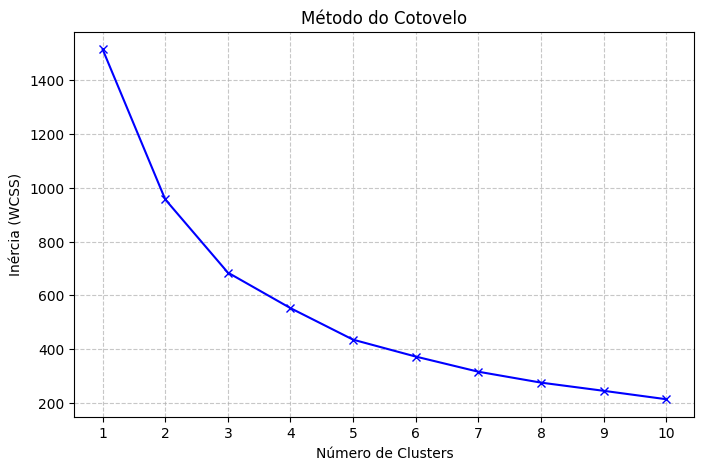

In [ ]:
C_train_t = cluster_preprocessor.fit_transform(C_train)

# ======= Definição do melhor K com método do cotovelo ======= #
def plot_elbow_method(data, max_k=10):
    inertias = []
    k_range = range(1, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertias, 'bx-')
    plt.xlabel('Número de Clusters')
    plt.ylabel('Inércia (WCSS)')
    plt.title('Método do Cotovelo')
    plt.xticks(k_range)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Executando para os dados de treino escalonados
plot_elbow_method(C_train_t)

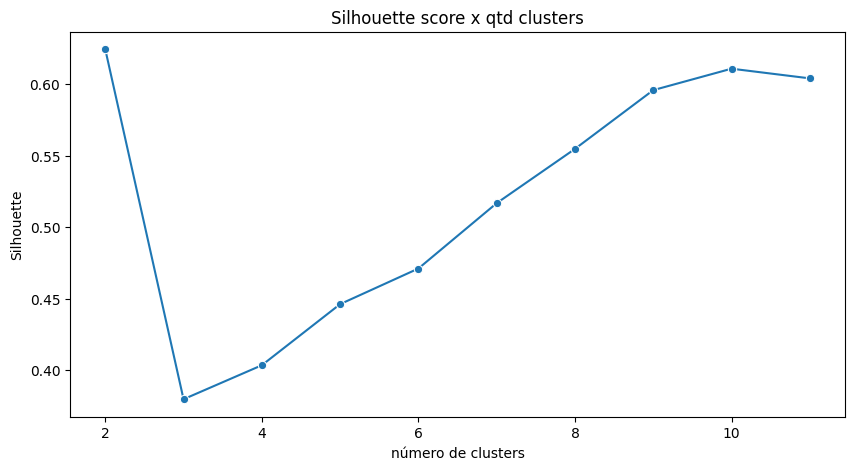

In [ ]:
# ======= Definição do melhor K com método da silhoueta ======= #
silhouette_results = []

for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(C_train_t)
    score = silhouette_score(C_train_t, labels)
    silhouette_results.append({"k": k, "silhouette": score})

silhouette_df = pd.DataFrame(silhouette_results)

plt.figure(figsize=(10, 5))
sns.lineplot(data=silhouette_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette score x qtd clusters")
plt.xlabel("número de clusters")
plt.ylabel("Silhouette")
plt.show()

Análise da definição de K:


> Seguindo a regra do cotovelo, uma divisão em grupos de 3 a 7 poderia trazer resultados significativos, observando a gráfico da silhoueta, os maiories números são 2 e 10 sendo 2 a melhor divisão.
O 2 também poderia ser considerado na regra do cotovelo mas dá pra perceber que não existe uma divisão de clusters muito conclusiva: o valor da inércia com 2 fica muito alto e as escolhas entre 3 e 7 na shilhoueta tem uma aproximação muito grande entre as classes!

**Conclusão:**
Vale á pena testar a divisão em 2 grupos e a divisão em 7 ou 8 grupos e escolher qual é a melhor com base a análise dos clusters




#### **Análise de divisão em 8 clusters**

Entre 7 e 8, 8 foi escolhido por gerar uma divisão perfeita por classes. Por tanto, essa análise vai focar na análise por classes.

In [ ]:
# Definir K manualmente
kmeans8 = KMeans(n_clusters=8, random_state=SEED, n_init=20)
kmeans8.fit(C_train_t)

KMeans(n_init=20, random_state=42)

In [ ]:
def add_cluster_features(X_original, preprocessor, kmeans_model, cluster_features):
    X_new = X_original.copy()
    C = preprocessor.transform(X_new[cluster_features])
    X_new["cluster_id"] = kmeans_model.predict(C).astype(str)
    X_new["cluster_distance"] = kmeans_model.transform(C).min(axis=1)
    return X_new

X_train_eng8 = add_cluster_features(X_train_manual, cluster_preprocessor, kmeans8, cluster_features)



In [ ]:
profiles = X_train.copy()
profiles["cluster_id"] = X_train_eng8["cluster_id"].values
profiles["target"] = y_train.values

# features numéricas em relação ao target
cluster_summary_num = profiles.groupby("cluster_id").agg(
    n=("cluster_id", "size"),
    mean_age=("age", "mean"),
    Criança_count=("age", lambda x: (x < 12).sum()),
    Adoles_count=("age", lambda x: ((x <= 12) & (x < 21)).sum()),
    Jovem_count=("age", lambda x: ((x >= 21) & (x < 31)).sum()),
    Jovem_Adulto_count=("age", lambda x: ((x >= 31) & (x < 41)).sum()),
    Adulto_count=("age", lambda x: ((x >= 41) & (x < 61)).sum()),
    Idoso_count=("age", lambda x: (x >= 61).sum()),
    mean_fare=("fare", "mean"),
    mean_sibsp=("sibsp", "mean"),
    mean_parch=("parch", "mean"),
    mean_pclass=("pclass", "mean"),
    var_pclass=("pclass", "var"),
    survival_rate=("target", "mean")

).round(3)
# comparação da feature deck apenas para ajudar da identificação do profiling
df_t['deck'] = df_t['deck'].fillna('missing')
profiles['deck'] = df_t['deck']

cluster_summary_cat = profiles.groupby("cluster_id").agg(
    n=("cluster_id", "size"),
    sex_female_count=("sex", lambda x: (x == 'female').sum()),
    sex_male_count=("sex", lambda x: (x == 'male').sum()),
    embarked_C_count=("embarked", lambda x: (x == 'C').sum()),
    embarked_Q_count=("embarked", lambda x: (x == 'Q').sum()),
    embarked_S_count=("embarked", lambda x: (x == 'S').sum()),
    deck_ABC_count=("deck", lambda x: ((x == "A") | (x == "B")|  (x == "C") ).sum()),
    deck_DE_count=("deck", lambda x: ((x == "D") | (x == "E")).sum()),
    deck_FG_count=("deck", lambda x: ((x == "F") | (x == "G")).sum()),
    deck_missing_count=("deck", lambda x: (x == "missing").sum()),
    survival_rate=("target", "mean")
).round(3)

cluster_summary_num = cluster_summary_num.sort_values(by='survival_rate', ascending=False)
cluster_summary_cat = cluster_summary_cat.sort_values(by='survival_rate', ascending=False)
display(cluster_summary_num)
print(f"\n{'■■'*100}")
display(cluster_summary_cat)

,n,mean_age,Criança_count,Adoles_count,Jovem_count,Jovem_Adulto_count,Adulto_count,Idoso_count,mean_fare,mean_sibsp,mean_parch,mean_pclass,var_pclass,survival_rate
cluster_id,,,,,,,,,,,,,,
6,66,27.173,8,9,21,13,11,0,23.586,0.500,0.758,2.0,0.0,0.864
1,65,35.821,4,4,12,17,23,1,97.030,0.600,0.462,1.0,0.0,0.815
3,21,35.750,0,0,6,4,5,2,254.705,1.000,1.238,1.0,0.0,0.667
5,97,22.235,20,20,27,13,5,1,16.889,1.021,0.990,3.0,0.0,0.485
7,100,40.750,1,1,15,19,34,9,38.293,0.270,0.130,1.0,0.0,0.440
4,105,24.466,5,6,17,10,1,1,9.852,0.295,0.181,3.0,0.0,0.286
0,228,25.488,16,16,72,36,14,1,14.348,0.561,0.320,3.0,0.0,0.167
2,103,29.306,7,7,35,20,15,2,19.681,0.330,0.184,2.0,0.0,0.165



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■


,n,sex_female_count,sex_male_count,embarked_C_count,embarked_Q_count,embarked_S_count,deck_ABC_count,deck_DE_count,deck_FG_count,deck_missing_count,survival_rate
cluster_id,,,,,,,,,,,
6,66,66,0,6,0,60,0,3,2,61,0.864
1,65,47,18,40,3,22,40,17,0,8,0.815
3,21,13,8,14,0,7,19,0,0,2,0.667
5,97,97,0,24,0,73,0,0,3,94,0.485
7,100,18,82,26,0,74,44,28,0,28,0.440
4,105,32,73,40,65,0,0,0,2,103,0.286
0,228,0,228,0,0,228,0,0,2,226,0.167
2,103,0,103,11,1,91,0,2,3,98,0.165


##### **Observação inicial dos clusters formado**s:

aqui, a **acurácia** significa quanto% das pessoas se qualificam na descrição dada à classes e foi feita com base na análise expecífica de clusters logo abaixo.

| id | descrição | acurácia |
|--------|------| ------|
|6| Mulheres da 2ª classe |**100%** |
|1| Adultos de 1ª Classe acompanhados |**70%** |
|3| Pessoas da 1ª Classe acompanhadas| **76%**
|5| Mulheres jovens desacompanhadas e adultas acompanhadas da 3ª Classe | **81%**
|7| Adultos desacompanhados da 1ª Classe | **77%** | Upper
|4| Jovens e adultos da 3ª Classe desacompanhados | **77%**
|0| Homens da 3ª classe desacompanhados | **77%**
|2| Homens da 2ª classe | **100%**


#### **Observações sobre o k = 8**:
1. Independente da classe/cluster as mulheres sempre tem uma chance muito maior de sobrevivência.
2. As divisões foram muito baseadas em gênero, ter ou não companhia, e grupo etário.
3. Ter ou não companhia não impacta muito na chance de sobrevivência quando você é mulher
4. A segunda classe foi perfeitamente dividida por sexo
5. A divisão em 2 clusters parece ter grande relação com o gênero, com base nas observações do k = 8
6. Apesar disso, é perceptível a influência das classes na sobrevivência, mulheres da primeira e segunda classe foram bastante beneficiadas nas chances de sobrevivência
7. O cluster 1 é muito heterogêneo e o cluster 3 é muito pequeno, talvez poderia ser testada uma divisão maior de clusters e a incorporaçao do cluster 3 com o cluster 7

###### **observação detalhada da 1ª classe**

In [ ]:
# ====== observação da primeira classe ====== #

youth_1_class  = profiles[
    (profiles['pclass'] == 1) &
    ((profiles['age'] <= 21 ))
].groupby(['cluster_id', 'sex']).agg(
    n=('age', 'size'),
    parch_25=('parch', lambda x: x.quantile(0.25)),
    median_parch=('parch', 'median'),
    mean_parch=('parch', 'mean'),
    median_sibsp=('sibsp', 'median'),
    mean_sibsp=('sibsp', 'mean'),
    survival_rate=('target', 'mean')
).reset_index().round(3)

print(f"{' '*22}ANÁLISE DE JOVENS DA PRIMEIRA CLASSE")
display(youth_1_class)
print(f"\n{'■■'*50}")


man_1_class  = profiles[
    (profiles['pclass'] == 1) &
    ((profiles['sex'] == 'male'))
].groupby(['cluster_id']).agg(
    n=('age', 'size'),
    age_25=('age', lambda x: x.quantile(0.25)),
    parch_25=('parch', lambda x: x.quantile(0.25)),
    median_parch=('parch', 'median'),
    mean_parch=('parch', 'mean'),
    median_sibsp=('sibsp', 'median'),
    mean_sibsp=('sibsp', 'mean'),
    survival_rate=('target', 'mean')
).reset_index().round(3)

print(f" {' '*22}ANÁLISE DE HOMENS DA PRIMEIRA CLASSE")
display(man_1_class)
print(f"\n{'■■'*50}")

woman_1_class  = profiles[
    (profiles['pclass'] == 1) &
    ((profiles['sex'] == 'female'))
].groupby(['cluster_id']).agg(
    n=('age', 'size'),
    median_age=('age', 'median'),
    mean_age=('age', 'mean'),
    parch_25=('parch', lambda x: x.quantile(0.25)),
    median_parch=('parch', 'median'),
    mean_parch=('parch', 'mean'),
    median_sibsp=('sibsp', 'median'),
    mean_sibsp=('sibsp', 'mean'),
    survival_rate=('target', 'mean')
).reset_index().round(3)

print(f" {' '*22}ANÁLISE DE MULHERES DA PRIMEIRA CLASSE")
display(woman_1_class)

                      ANÁLISE DE JOVENS DA PRIMEIRA CLASSE


/tmp/ipykernel_714/2493038641.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,cluster_id,sex,n,parch_25,median_parch,mean_parch,median_sibsp,mean_sibsp,survival_rate
0,1,female,6,0.0,1.0,1.000,1.0,0.667,0.833
1,1,male,3,2.0,2.0,2.000,1.0,0.667,1.000
2,3,female,3,1.0,2.0,1.333,2.0,1.667,1.000
3,3,male,1,2.0,2.0,2.000,3.0,3.000,0.000
4,7,female,4,0.0,0.5,0.750,0.5,0.500,1.000
5,7,male,5,0.0,1.0,0.800,0.0,0.200,0.400



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
                       ANÁLISE DE HOMENS DA PRIMEIRA CLASSE


,cluster_id,n,age_25,parch_25,median_parch,mean_parch,median_sibsp,mean_sibsp,survival_rate
0,1,18,27.0,0.00,0.0,0.667,1.0,0.667,0.389
1,3,8,30.0,0.75,1.0,1.500,1.0,0.875,0.125
2,7,82,31.0,0.00,0.0,0.110,0.0,0.207,0.329



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
                       ANÁLISE DE MULHERES DA PRIMEIRA CLASSE


,cluster_id,n,median_age,mean_age,parch_25,median_parch,mean_parch,median_sibsp,mean_sibsp,survival_rate
0,1,47,34.0,34.932,0.0,0.0,0.383,1.0,0.574,0.979
1,3,13,29.0,31.846,0.0,1.0,1.077,1.0,1.077,1.000
2,7,18,39.0,37.667,0.0,0.0,0.222,0.5,0.556,0.944


In [ ]:
# Contagem de "outliers" cluster 1
cluster_1 = profiles[profiles['cluster_id'] == '1']
# Pessoas com 21 anos ou mais e ao menos um sibsp ou parch
count_family_c1 = cluster_1[
    (cluster_1['sibsp'] + cluster_1['parch'] == 0)
].shape[0]

print(f"Cluster 1 #Adultos com acompanhante# :")
print(f"Adultos sem acomapanhante no cluster: {count_family_c1}")
print(f"acurácia na identificação do cluster: {(65-count_family_c1)/65}")
print(f"{'■■'*20}")

# Contagem de "outliers" cluster 3
cluster_3= profiles[profiles['cluster_id'] == '3']
# Pessoas com menos de 1 sibsp/parch
count_family_c3 = cluster_3[
    (cluster_3['sibsp'] + cluster_3['parch'] == 0)
].shape[0]

print(f"No Cluster 3 #Pessoas com acompanhante# :")
print(f"Pessoas sem acomapanhante no cluster: {count_family_c3}")
print(f"acurácia na identificação do cluster: {(21-count_family_c3)/21}")
print(f"{'■■'*20}")

# Contagem de "outliers" cluster 7
cluster_7 = profiles[profiles['cluster_id'] == '7']
# Pessoas acompanhadas
count_family_c7 = cluster_7[
    (cluster_7['sibsp'] + cluster_7['parch'] >= 1)
].shape[0]
# Crianças adolescentes
count_adult_c7 = cluster_7[
    (cluster_7['age'] <= 21)
].shape[0]


print(f"Cluster 7 #Adultos desacompanhados#: ")
print(f"Adultos com ao menos 1 parente/relacionamento: {count_family_c7}")
print(f"Não adultos no cluster: {count_adult_c7}")
print(f"acurácia de faixa etária no cluster: {(100-(count_adult_c7))/100}")
print(f"acurácia de acompanhamento no cluster: {(100-(count_family_c7))/100}")
print(f"acurácia média do cluster: {(((100-(count_adult_c7))/100)+((100-(count_family_c7))/100))/2}")
print(f"{'■■'*20}")

# Se os clusters 1 e 3 forem unificados
print("Cluster 1 + 3 #Pessoas sem acompanhante# : ")
print(f"Pessoas com acompanhante no cluster: {count_family_c3+count_family_c1}")
print(f"acurácia na identificação do cluster: {(86-(count_family_c3+count_family_c1))/86}")

Cluster 1 #Adultos com acompanhante# :
Adultos sem acomapanhante no cluster: 19
acurácia na identificação do cluster: 0.7076923076923077
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
No Cluster 3 #Pessoas com acompanhante# :
Pessoas sem acomapanhante no cluster: 5
acurácia na identificação do cluster: 0.7619047619047619
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Cluster 7 #Adultos desacompanhados#: 
Adultos com ao menos 1 parente/relacionamento: 36
Não adultos no cluster: 9
acurácia de faixa etária no cluster: 0.91
acurácia de acompanhamento no cluster: 0.64
acurácia média do cluster: 0.775
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Cluster 1 + 3 #Pessoas sem acompanhante# : 
Pessoas com acompanhante no cluster: 24
acurácia na identificação do cluster: 0.7209302325581395


###### **observação detalhada da 3ª classe**

In [ ]:
# ====== observação da terceira classe ====== #

youth_3_class  = profiles[
    (profiles['pclass'] == 3) &
    ((profiles['age'] <= 21 ))
].groupby(['cluster_id', 'sex']).agg(
    n=('age', 'size'),
    parch_25=('parch', lambda x: x.quantile(0.25)),
    median_parch=('parch', 'median'),
    mean_parch=('parch', 'mean'),
    median_sibsp=('sibsp', 'median'),
    mean_sibsp=('sibsp', 'mean'),
    survival_rate=('target', 'mean')
).reset_index().round(3)

print(f"{' '*22}ANÁLISE DE JOVENS DA TERCEIRA CLASSE")
display(youth_3_class)
print(f"\n{'■■'*50}")

man_3_class  = profiles[
    (profiles['pclass'] == 3) &
    ((profiles['sex'] == 'male'))
].groupby(['cluster_id']).agg(
    n=('age', 'size'),
    median_age=('age', 'median'),
    mean_age=('age', 'mean'),
    parch_25=('parch', lambda x: x.quantile(0.25)),
    median_parch=('parch', 'median'),
    mean_parch=('parch', 'mean'),
    median_sibsp=('sibsp', 'median'),
    mean_sibsp=('sibsp', 'mean'),
    survival_rate=('target', 'mean')
).reset_index().round(3)

print(f" {' '*22}ANÁLISE DE HOMENS DA TERCEIRA CLASSE")
display(man_3_class)
print(f"\n{'■■'*50}")

woman_3_class  = profiles[
    (profiles['pclass'] == 3) &
    ((profiles['sex'] == 'female'))
].groupby(['cluster_id']).agg(
    n=('age', 'size'),
    median_age=('age', 'median'),
    mean_age=('age', 'mean'),
    parch_25=('parch', lambda x: x.quantile(0.25)),
    median_parch=('parch', 'median'),
    mean_parch=('parch', 'mean'),
    median_sibsp=('sibsp', 'median'),
    mean_sibsp=('sibsp', 'mean'),
    survival_rate=('target', 'mean')
).reset_index().round(3)

print(f" {' '*22}ANÁLISE DE MULHERES DA TERCEIRA CLASSE")
display(woman_3_class)

                      ANÁLISE DE JOVENS DA TERCEIRA CLASSE


/tmp/ipykernel_714/202959279.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,cluster_id,sex,n,parch_25,median_parch,mean_parch,median_sibsp,mean_sibsp,survival_rate
0,0,female,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0,male,64,0.0,0.0,0.547,0.0,1.062,0.219
2,4,female,7,0.0,0.0,0.000,0.0,0.000,0.286
3,4,male,13,0.0,0.0,0.462,1.0,1.231,0.385
4,5,female,35,0.0,1.0,0.971,1.0,1.657,0.543
5,5,male,0,NaN,NaN,NaN,NaN,NaN,NaN



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
                       ANÁLISE DE HOMENS DA TERCEIRA CLASSE


,cluster_id,n,median_age,mean_age,parch_25,median_parch,mean_parch,median_sibsp,mean_sibsp,survival_rate
0,0,228,24.00,25.488,0.0,0.0,0.320,0.0,0.561,0.167
1,4,73,23.75,24.482,0.0,0.0,0.151,0.0,0.356,0.219



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
                       ANÁLISE DE MULHERES DA TERCEIRA CLASSE


,cluster_id,n,median_age,mean_age,parch_25,median_parch,mean_parch,median_sibsp,mean_sibsp,survival_rate
0,4,32,24.0,24.433,0.0,0.0,0.25,0.0,0.156,0.438
1,5,97,23.0,22.235,0.0,1.0,0.99,1.0,1.021,0.485


In [ ]:
# Contagem de "outliers" cluster 0
cluster_0= profiles[profiles['cluster_id'] == '0']
# Pessoas com menos de 1 sibsp/parch
count_family_c0 = cluster_0[
    (cluster_0['sibsp'] + cluster_0['parch'] > 0)
].shape[0]

print(f"No Cluster 0:  #Homens desacompanhadas#")
print(f"Homens acompanhados no cluster: {count_family_c0}")
print(f"acurácia na identificação do cluster: {(228-count_family_c0)/228}")
print(f"{'■■'*20}")

# Contagem de "outliers" cluster 4
cluster_4 = profiles[profiles['cluster_id'] == '4']
# Pessoas com menos de 1 sibsp/parch
count_family_c4 = cluster_4[
    (cluster_4['sibsp'] + cluster_4['parch'] > 0)
].shape[0]

print(f"Cluster 4:")
print(f"Jovens com +1 parente: {count_family_c4}")
print(f"acurácia na identificação do cluster: {(105-count_family_c4)/105}")
print(f"{'■■'*20}")

# Contagem de "outliers" cluster 5
cluster_5 = profiles[profiles['cluster_id'] == '5']
# Pessoas com menos de 1 sibsp/parch
count_family_c5 = cluster_5[
    (cluster_5['age'] > 31) &
    (cluster_5['sibsp'] + cluster_5['parch'] > 0)
].shape[0]
count_youth_c5 = cluster_5[
    (cluster_5['age'] <= 31) &
    (cluster_5['sibsp'] + cluster_5['parch'] == 0)
].shape[0]

print(f"Cluster 5:  #Mulheres jovens desacompanhadas e adultas acompanhadas da 3ª Classe #")
print(f"Mulheres desacomapanhadas no cluster: {count_family_c5}")
print(f"Mulheres mais velhas no cluster: {count_youth_c5}")
print(f"acurácia acompanhamento no cluster: {(97-count_family_c5)/97}")
print(f"acurácia faixa etária cluster: {(97-count_youth_c5)/97}")
print(f"acurácia média do cluster: {(((97-count_family_c5)/97)+((97-count_youth_c5)/97))/2}")

No Cluster 0:  #Homens desacompanhadas#
Homens acompanhados no cluster: 52
acurácia na identificação do cluster: 0.7719298245614035
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Cluster 4:
Jovens com +1 parente: 24
acurácia na identificação do cluster: 0.7714285714285715
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Cluster 5:  #Mulheres jovens desacompanhadas e adultas acompanhadas da 3ª Classe #
Mulheres desacomapanhadas no cluster: 12
Mulheres mais velhas no cluster: 23
acurácia acompanhamento no cluster: 0.8762886597938144
acurácia faixa etária cluster: 0.7628865979381443
acurácia média do cluster: 0.8195876288659794


#### **Análise com 2 clusters:**


In [ ]:
# Definir K manualmente
kmeans2 = KMeans(n_clusters=2, random_state=SEED, n_init=20)
kmeans2.fit(C_train_t)

X_train_eng2 = add_cluster_features(X_train_manual, cluster_preprocessor, kmeans2, cluster_features)

In [ ]:
profiles2 = X_train.copy()
profiles2["cluster_id"] = X_train_eng2["cluster_id"].values
profiles2["target"] = y_train.values

# features numéricas em relação ao target
cluster_summary_num = profiles2.groupby("cluster_id").agg(
    n=("cluster_id", "size"),
    mean_age=("age", "mean"),
    Criança_count=("age", lambda x: (x < 12).sum()),
    Adoles_count=("age", lambda x: ((x <= 12) & (x < 21)).sum()),
    Jovem_count=("age", lambda x: ((x >= 21) & (x < 31)).sum()),
    Jovem_Adulto_count=("age", lambda x: ((x >= 31) & (x < 41)).sum()),
    Adulto_count=("age", lambda x: ((x >= 41) & (x < 61)).sum()),
    Idoso_count=("age", lambda x: (x >= 61).sum()),
    mean_fare=("fare", "mean"),
    mean_sibsp=("sibsp", "mean"),
    mean_parch=("parch", "mean"),
    mean_pclass=("pclass", "mean"),
    var_pclass=("pclass", "var"),
    survival_rate=("target", "mean")

).round(3)

# comparação da feature deck apenas para ajudar da identificação do profiling
profiles2['deck'] = df_t['deck']

cluster_summary_cat = profiles2.groupby("cluster_id").agg(
    n=("cluster_id", "size"),
    sex_female_count=("sex", lambda x: (x == 'female').sum()),
    sex_male_count=("sex", lambda x: (x == 'male').sum()),
    embarked_C_count=("embarked", lambda x: (x == 'C').sum()),
    embarked_Q_count=("embarked", lambda x: (x == 'Q').sum()),
    embarked_S_count=("embarked", lambda x: (x == 'S').sum()),
    deck_ABC_count=("deck", lambda x: ((x == "A") | (x == "B")|  (x == "C") ).sum()),
    deck_DE_count=("deck", lambda x: ((x == "D") | (x == "E")).sum()),
    deck_FG_count=("deck", lambda x: ((x == "F") | (x == "G")).sum()),
    deck_missing_count=("deck", lambda x: (x == "missing").sum()),
    survival_rate=("target", "mean")

).round(3)

cluster_summary_num = cluster_summary_num.sort_values(by='survival_rate', ascending=False)
cluster_summary_cat = cluster_summary_cat.sort_values(by='survival_rate', ascending=False)

display(cluster_summary_num)
display(cluster_summary_cat)

,n,mean_age,Criança_count,Adoles_count,Jovem_count,Jovem_Adulto_count,Adulto_count,Idoso_count,mean_fare,mean_sibsp,mean_parch,mean_pclass,var_pclass,survival_rate
cluster_id,,,,,,,,,,,,,,
0,44,32.096,4,4,9,12,9,2,191.882,0.818,1.000,1.000,0.000,0.727
1,741,28.920,57,59,196,120,99,15,22.362,0.507,0.381,2.389,0.622,0.362


,n,sex_female_count,sex_male_count,embarked_C_count,embarked_Q_count,embarked_S_count,deck_ABC_count,deck_DE_count,deck_FG_count,deck_missing_count,survival_rate
cluster_id,,,,,,,,,,,
0,44,27,17,25,0,19,31,6,0,7,0.727
1,741,246,495,136,69,536,72,44,12,613,0.362


##### **Observação dos clusters formados**:

aqui, a **acurácia** significa quanto% das pessoas se qualificam na descrição dada à classes e foi feita com base na análise expecífica de clusters logo abaixo.

| id | descrição | acurácia
|--------|------| ------|
|0| Pessoas da 1ª classe |**100%**
|1| Pessoas da primeira e demais classes |desc.| Indefinido



#### **Observações sobre o k = 2**:
1. As informações dessa divisão são muito mescladas, existe uma grande diversidade de observações, em especial no cluster 1.
2. O cluster 0 tem apenas pessoas da primeira classe (mas não todas) e tem uma taxa de sobrevivência alta
3. Essa divisão não parece contribuir para a análise e se solidificar como uma feature explicável então será descontinuada

In [ ]:
cluster2_1 = profiles2[profiles2['cluster_id'] == '1']

# Contar quantas pessoas de cada classe existem no cluster 1
class_summary = cluster2_1.groupby(['cluster_id', 'pclass']).agg(
    n=('pclass', 'size')
).round(3)

class_summary

n
cluster_id pclass     
1          1       142
           2       169
           3       430

In [ ]:
# ======= Treinamento do modelo com k=8 ======= #
C_val_t = cluster_preprocessor.transform(C_train_val)
C_test_t = cluster_preprocessor.transform(C_test)

X_train_eng = add_cluster_features(X_train_manual, cluster_preprocessor, kmeans8, cluster_features)
X_val_eng = add_cluster_features(X_val_manual, cluster_preprocessor, kmeans8, cluster_features)
X_test_eng = add_cluster_features(X_test_manual, cluster_preprocessor, kmeans8, cluster_features)

X_train_eng[["cluster_id", "cluster_distance"]].head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros



,cluster_id,cluster_distance
287,7,0.340581
187,7,0.860552
954,0,0.235447
537,2,0.183534
1200,0,0.133371


In [ ]:
best_deck_model = baseline_searches_d['RandomForest_deck']['best_estimator']

deck_prediction_features = ['pclass', 'family_on_board', 'individual_fare', 'has_shared_ticket']

X_wo_deck_pred = df_wo_deck[deck_prediction_features].copy()

predicted_deck_labels_encoded = best_deck_model.predict(X_wo_deck_pred)
predicted_deck_labels = le.inverse_transform(predicted_deck_labels_encoded)
df_wo_deck['deck_grouped'] = predicted_deck_labels

display(df_wo_deck[['pclass', 'individual_fare', 'deck_grouped']].head())

,pclass,individual_fare,deck_grouped
9,1,49.504200,Upper
13,1,26.283333,Mid
15,1,25.925000,Mid
23,1,45.505000,Upper
25,1,26.000000,Mid


In [ ]:
df_all_decks = pd.concat([df_w_deck, df_wo_deck], ignore_index=False)

X_train_eng['deck_grouped'] = df_all_decks.loc[X_train_eng.index, 'deck_grouped']
X_val_eng['deck_grouped'] = df_all_decks.loc[X_val_eng.index, 'deck_grouped']
X_test_eng['deck_grouped'] = df_all_decks.loc[X_test_eng.index, 'deck_grouped']

display(X_train_eng[['pclass', 'sex', 'individual_fare', 'deck_grouped']].head())

,pclass,sex,individual_fare,deck_grouped
287,1,male,32.32080,Mid
187,1,female,19.70000,Mid
954,3,male,5.09334,Lower
537,2,male,6.50000,Lower
1200,3,male,8.05000,Lower


**Unindo os clusters 1 e 3:**




In [ ]:
X_train_eng['cluster_id'] = X_train_eng['cluster_id'].replace(['1', '3'], '1_3')
X_val_eng['cluster_id'] = X_val_eng['cluster_id'].replace(['1', '3'], '1_3')
X_test_eng['cluster_id'] = X_test_eng['cluster_id'].replace(['1', '3'], '1_3')

print("Clusters '1' e '3' re-rotulados para '1_3' nos conjuntos de treino, validação e teste.")

X_train_eng[['cluster_id', 'cluster_distance']].head()

Clusters '1' e '3' re-rotulados para '1_3' nos conjuntos de treino, validação e teste.


,cluster_id,cluster_distance
287,7,0.340581
187,7,0.860552
954,0,0.235447
537,2,0.183534
1200,0,0.133371


In [ ]:
plot_df = X_train_eng[['sex', 'pclass', 'fare', 'cluster_id']].copy()

fig = px.scatter_3d(plot_df, x="sex", y="pclass", z="fare", color="cluster_id")
fig.show()

### **7. MODELO ENRIQUECIDO COM PROFILING**

7.1 Avaliação das novas features

* dividir a feature em quartis;
* calcular a taza se sobrevivencia
* observar se existe separação relevante entre os quartis.

7.2 Enriquecimento do modelo

#### **7.1 Avaliação das novas features**

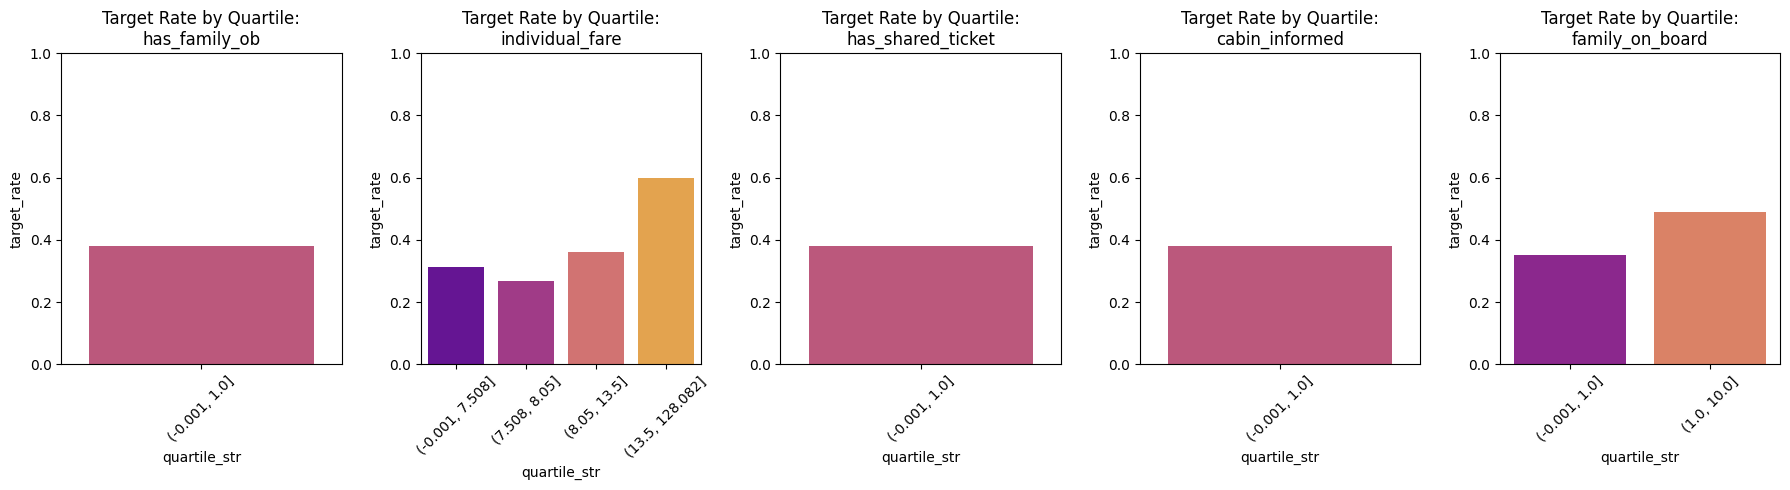

,feature,quartile_spread,monotonic_pattern
1,individual_fare,0.3320,False
5,cluster_distance,0.2687,True
4,family_on_board,0.1385,True
0,has_family_ob,0.0000,True
2,has_shared_ticket,0.0000,True
3,cabin_informed,0.0000,True


In [ ]:
# ===== funções de apoio ====== #
num_eng_features = manual_new_features + ["cluster_distance"]

# Análise de quartil em relação ao target (survived)
def quartile_target_analysis(X_features, y_target, features):
    ranking_rows = []
    detailed_tables = {}

    # Remoção de nulos
    for feature in features:
        temp = pd.DataFrame({
            "feature_value": X_features[feature],
            "target": y_target.values
        }).dropna()

        temp["quartile"] = pd.qcut(temp["feature_value"], q=4, duplicates="drop")

        # Agrupamento por quartis do target
        summary = (
            temp.groupby("quartile", observed=False)["target"]
            .agg(target_rate="mean", count="size")
            .reset_index()
        )

        target_rates = summary["target_rate"].values
        spread = float(np.max(target_rates) - np.min(target_rates))
        monotonic = bool(pd.Series(target_rates).is_monotonic_increasing or pd.Series(target_rates).is_monotonic_decreasing)

        ranking_rows.append({
            "feature": feature,
            "quartile_spread": round(spread, 4),
            "monotonic_pattern": monotonic
        })

        detailed_tables[feature] = summary

    ranking_df = pd.DataFrame(ranking_rows).sort_values(
        ["quartile_spread", "monotonic_pattern"],
        ascending=[False, False]
    )
    return ranking_df, detailed_tables

# seleção de features numéricas para plotar
quartile_ranking_df, quartile_detail_tables = quartile_target_analysis(
    X_train_eng, y_train, manual_num_cols+['cluster_distance']
)

fig, axes = plt.subplots(1, len(manual_num_cols), figsize=(18, 5))

# Plotagem de gráficos de barras por feature numérica
for i, feature in enumerate(manual_num_cols):
    df_plot = quartile_detail_tables[feature]

    df_plot["quartile_str"] = df_plot["quartile"].astype(str)

    sns.barplot(data=df_plot, x="quartile_str", y="target_rate", legend=False, ax=axes[i], palette="plasma", hue="quartile_str")
    axes[i].set_title(f"Target Rate by Quartile:\n{feature}")
    axes[i].set_xticks(range(len(df_plot['quartile_str'])))
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(quartile_ranking_df)

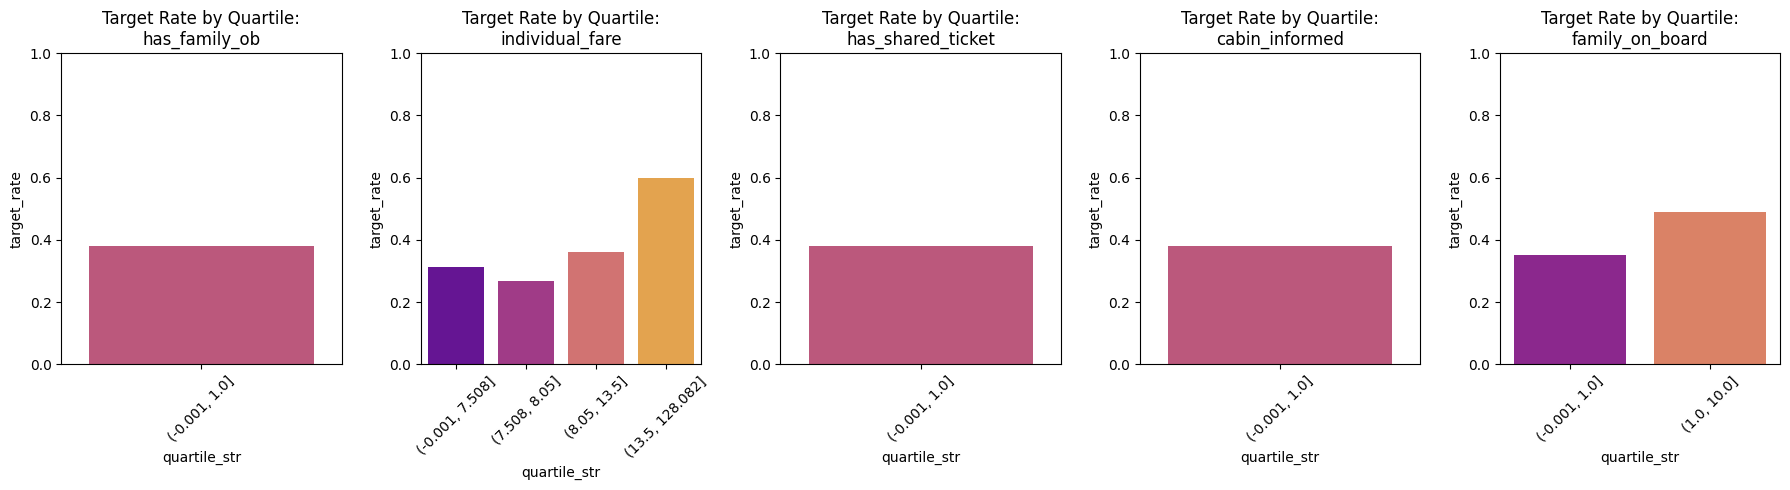

,feature,quartile_spread,monotonic_pattern
1,individual_fare,0.3320,False
5,cluster_distance,0.2687,True
4,family_on_board,0.1385,True
0,has_family_ob,0.0000,True
2,has_shared_ticket,0.0000,True
3,cabin_informed,0.0000,True


In [ ]:
# seleção de features numéricas para plotar
quartile_ranking_df, quartile_detail_tables = quartile_target_analysis(
    X_train_eng, y_train, manual_num_cols+['cluster_distance']
)

fig, axes = plt.subplots(1, len(manual_num_cols), figsize=(18, 5))

# plotagem de graficos de barras por feature numérica
for i, feature in enumerate(manual_num_cols):
    df_plot = quartile_detail_tables[feature]

    df_plot["quartile_str"] = df_plot["quartile"].astype(str)

    sns.barplot(data=df_plot, x="quartile_str", y="target_rate", legend=False, ax=axes[i], palette="plasma", hue="quartile_str")
    axes[i].set_title(f"Target Rate by Quartile:\n{feature}")
    axes[i].set_xticks(range(len(df_plot['quartile_str'])))
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(quartile_ranking_df)

In [ ]:
# ======= Seleção de features com spread >= 0.10 ou padrão monotônico == True ======= #

selected_numeric_eng = ["individual_fare", "cluster_distance", "family_on_board"]

Seria importante avaliar as features categóricas aqui mas, pelo tempo, não sei se é possível fazer isso, mas fica o registro

#### **7.2 Enriquecimento do modelo com profiling**

In [ ]:
enriched_numeric_features = selected_numeric_eng
enriched_categorical_features = ["cluster_id", "sex","pclass", "embarked", "position_class", "age_group"]
enriched_categorical_features.append('deck_grouped')

X_train_numeric_for_scaling = X_train_eng[enriched_numeric_features]
X_val_numeric_for_scaling = X_val_eng[enriched_numeric_features]
X_test_numeric_for_scaling = X_test_eng[enriched_numeric_features]

In [ ]:

def evaluate_on_validation(name, model, X_val, y_val, mode):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_proba)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=list(target_name_map.values())))

    return {"model_name": name, "accuracy": accuracy, "f1": f1, "roc_auc": roc_auc, "recall": recall, "precision": precision}, y_pred



In [ ]:
# ====== Pré-processamento ====== #

num_features_final = [
    "family_on_board",
    "individual_fare",
    "cluster_distance",
    #"has_shared_ticket"
]
cat_features_final = [
    "pclass",
    "sex",
    "embarked",
    #"deck_grouped",
    #"age_group",
    "position_class",
    "cluster_id"
]


num_pipe_final = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe_final = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', num_pipe_final, num_features_final),
        ('cat', cat_pipe_final, cat_features_final)
    ],
    remainder='drop'
)

In [ ]:
# ===== Modelos para o teste enriquecido ===== #
enriched_candidates = {
    "LogisticRegression_enriched": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor_final),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=SEED
            ))
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"],
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()]
        }
    },
    "RandomForest_enriched": {
        "pipeline": Pipeline([
            ('preprocessor', preprocessor_final),
            ("model", RandomForestClassifier(
                random_state=SEED,
                class_weight="balanced"
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [100, 150, 200],
            "model__max_depth": [None, 5, 10, 15],
            "model__min_samples_leaf": [1, 2, 5],
            "preprocessor__num__scaler": [StandardScaler(), MinMaxScaler()]
        }
    }
}

In [ ]:
# ========== Treinamento modelo ========== #
cv_f = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

prof_searches = {}
enriched_validation_results = []

for name, config in enriched_candidates.items():
    print(f"\n{'■■'*26}")
    print(f"Treinando: {name}")
    print(f"{'■■'*26}")

    grid_sf = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="f1",
        cv=cv_f,
        n_jobs=-1,
        refit=True
    )

    # treinamento
    grid_sf.fit(X_train_eng, y_train)

    prof_searches[name] = {
        'best_score': grid_sf.best_score_,
        'best_params': grid_sf.best_params_,
        'best_estimator': grid_sf.best_estimator_
    }

    print(f" Melhores parâmetros: {grid_sf.best_params_}")

    metrics, pred = evaluate_on_validation(name, grid_sf.best_estimator_, X_val_eng, y_val, mode="enriched")
    metrics["cv_best_score_f1"] = grid_sf.best_score_
    enriched_validation_results.append(metrics)

enriched_validation_df = pd.DataFrame(enriched_validation_results).sort_values("f1", ascending=False)
enriched_validation_df



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Treinando: LogisticRegression_enriched
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
 Melhores parâmetros: {'model__C': 0.01, 'model__solver': 'lbfgs', 'preprocessor__num__scaler': MinMaxScaler()}

Classification Report:
                precision    recall  f1-score   support

    Sobreviveu       0.89      0.73      0.80       162
Não sobreviveu       0.66      0.86      0.75       100

      accuracy                           0.78       262
     macro avg       0.78      0.79      0.78       262
  weighted avg       0.81      0.78      0.78       262


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Treinando: RandomForest_enriched
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
 Melhores parâmetros: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 100, 'preprocessor__num__scaler': StandardScaler()}

Classification Report:
                precision    recall  f1-score   support

    So

,model_name,accuracy,f1,roc_auc,recall,precision,cv_best_score_f1
0,LogisticRegression_enriched,0.778626,0.747826,0.860802,0.86,0.661538,0.673630
1,RandomForest_enriched,0.801527,0.740000,0.887222,0.74,0.740000,0.705376


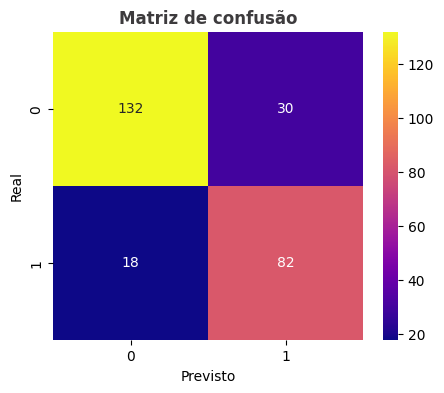


Classification report (Threshold: 0.47):
              precision    recall  f1-score   support

           0       0.88      0.81      0.85       162
           1       0.73      0.82      0.77       100

    accuracy                           0.82       262
   macro avg       0.81      0.82      0.81       262
weighted avg       0.82      0.82      0.82       262


Análise de sensibilidade do Threshold:
Threshold 0.2 -> Precision: 0.513 Recall: 0.970
Threshold 0.4 -> Precision: 0.697 Recall: 0.830
Threshold 0.5 -> Precision: 0.740 Recall: 0.740
Threshold 0.6 -> Precision: 0.778 Recall: 0.630
Threshold 0.7 -> Precision: 0.881 Recall: 0.520
Threshold 0.8 -> Precision: 0.917 Recall: 0.440


In [ ]:
best_model = prof_searches['RandomForest_enriched']['best_estimator']
y_probs_en = best_model.predict_proba(X_val_eng)[:, 1]

threshold = 0.47
pred_val_enriched = (y_probs_en >= threshold).astype(int)

plot_confusion(y_val, pred_val_enriched)

print(f"\nClassification report (Threshold: {threshold}):")
print(classification_report(y_val, pred_val_enriched, zero_division=0))

print("\nAnálise de sensibilidade do Threshold:")
for t in [0.2, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (y_probs_en >= t).astype(int)
    rec = recall_score(y_val, p)
    prec = precision_score(y_val, p)
    print(f"Threshold {t:.1f} -> Precision: {prec:.3f}",  f"Recall: {rec:.3f}")


| features removidas | LR F1 | LR CV | * | RF F1 | RF CV
|--------|------| ------| ------| ------| ------|
| nenhuma| 78 | 69|   *  | 77| 71    |
| age_group, deck_grouped| 74 | 70 |  *   | 76 | 67   |
| deck_grouped | 77 | 69|  *   | 76 | 70   |
| age_g, deck_g ,has_sh_ticket |  74 | 67| *   | 74 | 70   |
| position_class | 76 | 67 | *   | 76 | 69   |

### **8. COMPARAÇÃO DE RESULTADOS**

In [ ]:

baseline_rf_cv_score = baseline_searches['RandomForest']['best_score']
print(f"Baseline RandomForest - Melhor CV F1-Score: {baseline_rf_cv_score:.4f}")

selected_threshold_baseline = 0.45
y_probs_baseline = baseline_searches['RandomForest']['best_estimator'].predict_proba(X_val)[:, 1]
pred_val_baseline_thresholded = (y_probs_baseline >= selected_threshold_baseline).astype(int)
f1_baseline_val_thresholded = f1_score(y_val, pred_val_baseline_thresholded)
print(f"Baseline RandomForest - F1-Score na Validação com Threshold {selected_threshold_baseline}: {f1_baseline_val_thresholded:.4f}")

print(f"\n{'■■'*35}")

enriched_rf_cv_score = prof_searches['RandomForest_enriched']['best_score']
print(f"Enriched RandomForest - Melhor CV F1-Score: {enriched_rf_cv_score:.4f}")

selected_threshold_enriched = 0.47
y_probs_enriched = prof_searches['RandomForest_enriched']['best_estimator'].predict_proba(X_val_eng)[:, 1]
pred_val_enriched_thresholded = (y_probs_enriched >= selected_threshold_enriched).astype(int)
f1_enriched_val_thresholded = f1_score(y_val, pred_val_enriched_thresholded)
print(f"Enriched RandomForest - F1-Score na Validação com Threshold {selected_threshold_enriched}: {f1_enriched_val_thresholded:.4f}")


Baseline RandomForest - Melhor CV F1-Score: 0.6918
Baseline RandomForest - F1-Score na Validação com Threshold 0.45: 0.7327

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
Enriched RandomForest - Melhor CV F1-Score: 0.7054
Enriched RandomForest - F1-Score na Validação com Threshold 0.47: 0.7736


#### **8.1 Comparação dos Classification Reports**

In [ ]:
# Classification Report para o Modelo Baseline (RandomForest)
baseline_best_model = baseline_searches['RandomForest']['best_estimator']
y_probs_baseline_val = baseline_best_model.predict_proba(X_val)[:, 1]
selected_threshold_baseline = 0.45 # Threshold previamente selecionado
pred_val_baseline_thresholded = (y_probs_baseline_val >= selected_threshold_baseline).astype(int)

enriched_best_model = prof_searches['RandomForest_enriched']['best_estimator']
y_probs_enriched_val = enriched_best_model.predict_proba(X_val_eng)[:, 1]
selected_threshold_enriched = 0.47 # Threshold previamente selecionado
pred_val_enriched_thresholded = (y_probs_enriched_val >= selected_threshold_enriched).astype(int)
print()

print(classification_report(y_val, pred_val_enriched_thresholded, target_names=list(target_name_map.values())))

print(f"\n{'■■'*30}")

print(f"\nClassification Report - Modelo Baseline (Threshold: {selected_threshold_baseline}):")
print(classification_report(y_val, pred_val_baseline_thresholded, target_names=list(target_name_map.values())))



                precision    recall  f1-score   support

    Sobreviveu       0.88      0.81      0.85       162
Não sobreviveu       0.73      0.82      0.77       100

      accuracy                           0.82       262
     macro avg       0.81      0.82      0.81       262
  weighted avg       0.82      0.82      0.82       262


■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

Classification Report - Modelo Baseline (Threshold: 0.45):
                precision    recall  f1-score   support

    Sobreviveu       0.84      0.83      0.83       162
Não sobreviveu       0.73      0.74      0.73       100

      accuracy                           0.79       262
     macro avg       0.78      0.78      0.78       262
  weighted avg       0.79      0.79      0.79       262



In [ ]:
best_enriched_rf_model = prof_searches['RandomForest_enriched']['best_estimator']
preprocessor = best_enriched_rf_model.named_steps['preprocessor']
num_feature_names = num_features_final

cat_transformer = preprocessor.named_transformers_['cat']
cat_feature_names = cat_transformer.named_steps['onehot'].get_feature_names_out(cat_features_final)

all_feature_names = list(num_feature_names) + list(cat_feature_names)

rf_model = best_enriched_rf_model.named_steps['model']
feature_importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Relevância': feature_importances
}).sort_values(by='Relevância', ascending=False)

display(importance_df)

,Feature,Relevância
1,individual_fare,0.218446
2,cluster_distance,0.218116
5,sex_male,0.215844
0,family_on_board,0.098222
15,cluster_id_6,0.052277
10,position_class_Front,0.035937
4,pclass_3,0.030090
12,cluster_id_2,0.023892
11,cluster_id_1_3,0.022233
7,embarked_S,0.019633


De forma geral, houve uma melhora entre os modelos, o enriquecido consegue acertar mais dados novos em comparação com o baseline (74% x 70%) e é um pouco menos consistente (3,5% x 2,4%) mas, ainda sim se mostra superior apesar de ter uma tendência mais conservadora.

Em relação aos parâmetros, o modelo enriquecido se mostra mais robusto: a profundidade da árvore é limitada (10), possui mais folhas (2), com a mesma quantidade de árvores (100). Como o primeiro modelo tem somente 1 folha e não tem profundidade limitada, ele pode estar decorando os dados de treino ou overfitando (regra única).

Em relação à métricas, a acurácia é superior em quase 10 pontos percentuais no modelo enriquecido e a precisão e recall balanceados são 3 pontos maiores. Observando as métricas mais específicas, com o threshold ótimo, o modelo baseline tem um balanceamento entre precisão e recall muito melhor, por isso, seu F1 é de 0.83  para sobreviventes e não sobreviventes. Porém, o segundo modelo prioriza o recall em detrimento da precisão, o que faz sentido no contexto de busca por sobreviventes. Ambos são melhores em identificar os não sobreviventes, provavelmente porque têm muitos mais dados de treino de não sobreviventes do que o oposto.

Sobre as features, a única feature categórica que incrementou no modelo foi position_class, as outras foram eliminadas, podendo ser reavaliado o critério para criação de features categóricas. Sobre a feature de clustering, avaliando a tabela ao lado, é perceptível a necessidade de sua inclusão, cluster_distance teve grande influência no modelo enriquecido mas, de modo geral, muitas features tiveram baixa influência poderia ser repensada a inclusão de outra feature de clustering relevante.


Foi importante a inclusão do clustering considerando que poucas variáveis originais eram realmente relevantes para identificar sobreviventes. Os clusters são interpretáveis, sua classificação está em volta de classe, sexo e se a pessoa viajou sozinha, características sociais fáceis de serem entendidas e explicadas, não foi um resultado meramente estatístico. Apesar da melhora não ter sido significativa (3 pontos percentuais) ela mostra possibilidades de investigação baseada nas separações feitas por ele. Como:
Criação de features manuais de fare baseadas na idade das pessoas com mesmo ticket
Divisão dos dados em homens e mulheres para fazer a predição por sexo, aumentando as chances de uma predição mais acertada já que as mulheres tem uma taxa de sobrevivência muito superior e os gêneros podem estar servindo de ruído um para o outro.
Identificação de pessoas jovens e adultas solteiras no navio etc.